# **Séries Temporelles**

## Télécharger les packages

In [1]:
%%capture
!pip3 install eurostat numpy pandas matplotlib dataframe_image statsmodels plotly kaleido seaborn polars

In [2]:
!pip3 list

Package                   Version
------------------------- -----------
aiohappyeyeballs          2.6.1
aiohttp                   3.13.3
aiosignal                 1.4.0
annotated-types           0.7.0
anyio                     4.11.0
appnope                   0.1.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.2
bleach                    6.3.0
blinker                   1.9.0
branca                    0.8.2
certifi                   2025.11.12
cffi                      2.0.0
charset-normalizer        3.4.4
choreographer             1.2.1
click                     8.3.1
comm                      0.2.3
commonmark                0.9.1
contourpy                 1.3.3
cssselect                 1.4.0
cssutils                  2.11.1
curl_cffi                 0.13.0
cycler            

## Mobilisation des packages

In [3]:
import os
import eurostat
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import statsmodels.api as sm
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import (
    acf,
    pacf,
    adfuller,
    add_trend,
    grangercausalitytests,
)

## Chemin d'accès

In [ ]:
os.chdir("/Users/marius/Documents/Git/Resultat")
print(os.getcwd())

/Users/marius/Documents/Resultat


# PARTIE 1 : 
## Récupérer les données issus d'Eurostat

### Série Exportation (X)

In [5]:
X = eurostat.get_data_df("namq_10_exi")
X = X[
    (X["unit"] == "CLV10_MEUR")
    & (X["na_item"] == "P6")
    & (X["s_adj"] == "SCA")
    & (X[r"geo\TIME_PERIOD"] == "LU")
]
X = X.dropna(axis=1)
X = X.iloc[:, 5:]
X = X.T
X = X.rename(columns={X.columns[0]: "X"})
X = np.log(X)
X = X.head(120)

# Version en différence de la série exportation
X_diff = X.diff().dropna()

### Série Importation (M)

In [6]:
M = eurostat.get_data_df("namq_10_exi")
M = M[
    (M["unit"] == "CLV10_MEUR")
    & (M["na_item"] == "P7")
    & (M["s_adj"] == "SCA")
    & (M[r"geo\TIME_PERIOD"] == "LU")
]
M = M.dropna(axis=1)
M = M.iloc[:, 5:]
M = M.T
M = M.rename(columns={M.columns[0]: "M"})
M = np.log(M)
M = M.head(120)

# Version en différence de la série importation
M_diff = M.diff().dropna()

## Exportation vers Excel

In [7]:
X.to_excel("XT.xlsx", index=False)

In [8]:
M.to_excel("MT.xlsx", index=False)

## Graphiques

### Pour le tableau de la FAC et FAP

In [9]:
X_fac = acf(
    X,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
XT = pd.DataFrame(X_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
X_fap = pacf(X, nlags=32, method="ywmle", alpha=None)
XTFAP = (
    pd.DataFrame(X_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
XT.insert(1, "FAP", XTFAP)
XT.iloc[:, 0] = XT.iloc[:, 0].shift(-1)
XT = XT.drop(XT.index[-1]).reset_index(drop=True)

XT[["FAC", "FAP", "Prob"]] = XT[["FAC", "FAP", "Prob"]].round(3)

XT[["Q-stat"]] = XT[["Q-stat"]].round(2)

XT.insert(0, "Lag", range(1, len(XT) + 1))

In [10]:
X_fac = acf(
    X_diff,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
XTD = pd.DataFrame(X_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
X_fap = pacf(X_diff, nlags=32, method="ywmle", alpha=None)
XTDFAP = (
    pd.DataFrame(X_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
XTD.insert(1, "FAP", XTDFAP)
XTD.iloc[:, 0] = XTD.iloc[:, 0].shift(-1)
XTD = XTD.drop(XTD.index[-1]).reset_index(drop=True)

XTD[["FAC", "FAP", "Prob"]] = XTD[["FAC", "FAP", "Prob"]].round(3)

XTD[["Q-stat"]] = XTD[["Q-stat"]].round(2)

XTD.insert(0, "Lag", range(1, len(XTD) + 1))


XTD.to_excel("XTDiff.xlsx", index=False)

In [11]:
M_fac = acf(
    M,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
MT = pd.DataFrame(M_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
M_fap = pacf(M, nlags=32, method="ywmle", alpha=None)
MTFAP = (
    pd.DataFrame(M_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
MT.insert(1, "FAP", MTFAP)
MT.iloc[:, 0] = MT.iloc[:, 0].shift(-1)
MT = MT.drop(MT.index[-1]).reset_index(drop=True)

MT[["FAC", "FAP", "Prob"]] = MT[["FAC", "FAP", "Prob"]].round(3)

MT[["Q-stat"]] = MT[["Q-stat"]].round(2)

MT.insert(0, "Lag", range(1, len(MT) + 1))

In [12]:
M_fac = acf(
    M_diff,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
MTD = pd.DataFrame(M_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
M_fap = pacf(M_diff, nlags=32, method="ywmle", alpha=None)
MTDFAP = (
    pd.DataFrame(M_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
MTD.insert(1, "FAP", MTDFAP)
MTD.iloc[:, 0] = MTD.iloc[:, 0].shift(-1)
MTD = MTD.drop(MTD.index[-1]).reset_index(drop=True)

MTD[["FAC", "FAP", "Prob"]] = MTD[["FAC", "FAP", "Prob"]].round(3)

MTD[["Q-stat"]] = MTD[["Q-stat"]].round(2)

MTD.insert(0, "Lag", range(1, len(MTD) + 1))

MTD.to_excel("MTDiff.xlsx", index=False)

### Transformation des données des deux séries pour le graphique

In [13]:
XM = pd.concat([X] + [M], axis=1)
XM = XM.rename(columns={"X": "lnX", "M": "lnM"})
XM.index = pd.date_range(start="1995-01-01", periods=120, freq="QS")
XM.index = pd.to_datetime(XM.index)

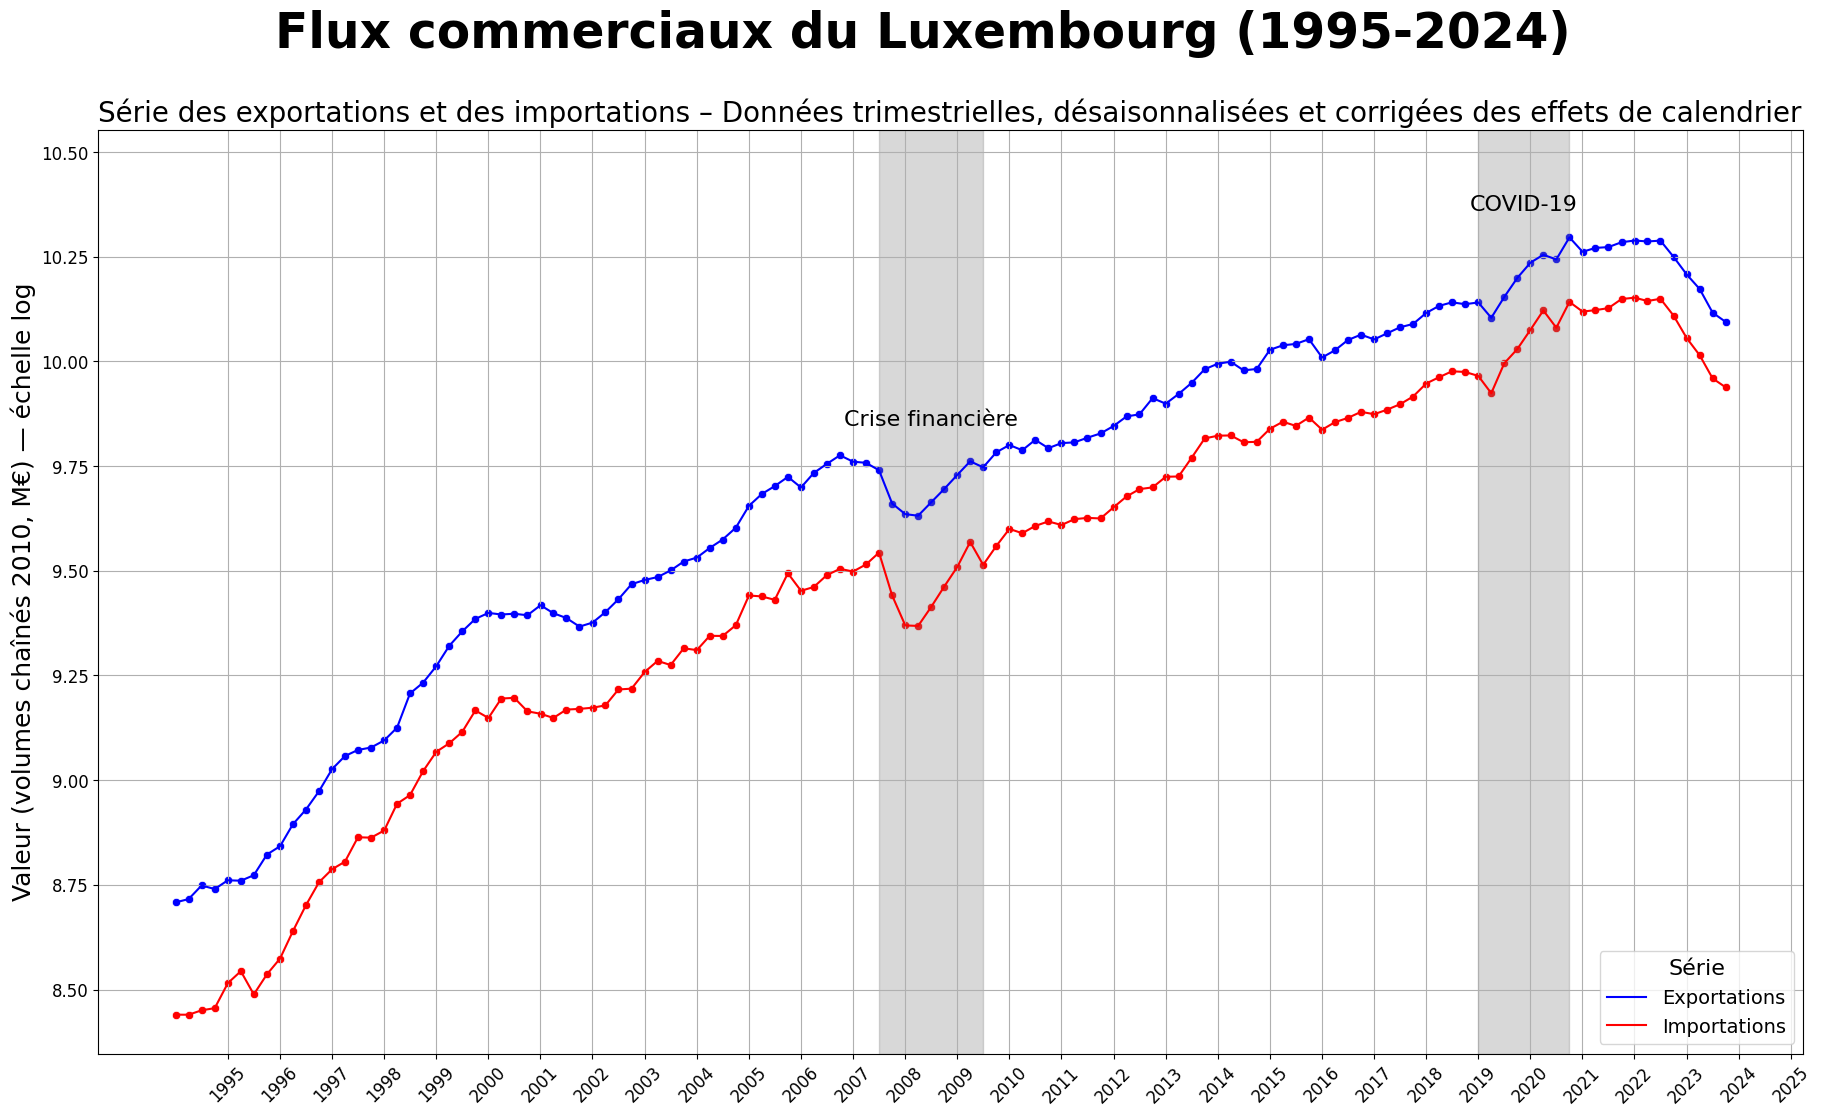

In [14]:
# Création de la figure et des axes
plt.figure(figsize=(22, 12))

# Tracé des courbes
sns.lineplot(data=XM, x=XM.index, y="lnX", color="blue", label="Exportations")
sns.scatterplot(data=XM, x=XM.index, y="lnX", color="blue")

sns.lineplot(data=XM, x=XM.index, y="lnM", color="red", label="Importations")
sns.scatterplot(data=XM, x=XM.index, y="lnM", color="red")

plt.ylim(top=XM[["lnX", "lnM"]].max().max() * 1.025)

# Zones grisées pour les crises
crise_fin_start = pd.Timestamp("2008-07-01")
crise_fin_end = pd.Timestamp("2010-06-30")
covid_start = pd.Timestamp("2020-01-01")
covid_end = pd.Timestamp("2021-09-30")

plt.axvspan(crise_fin_start, crise_fin_end, color="grey", alpha=0.3)
plt.axvspan(covid_start, covid_end, color="grey", alpha=0.3)

# Annotation des crises
plt.text(
    x=crise_fin_start + (crise_fin_end - crise_fin_start) / 2,
    y=XM[["lnX", "lnM"]].max().max() * 0.96,
    s="Crise financière",
    fontsize=16,
    ha="center",
    va="top",
    color="black",
)

plt.text(
    x=covid_start + (covid_end - covid_start) / 2,
    y=XM[["lnX", "lnM"]].max().max() * 1.01,
    s="COVID-19",
    fontsize=16,
    ha="center",
    va="top",
    color="black",
)

# Ajout du titre et des labels
plt.xlabel(None)
plt.ylabel("Valeur (volumes chaînés 2010, M€) — échelle log", fontsize=18)
plt.title(
    "Série des exportations et des importations – Données trimestrielles, désaisonnalisées et corrigées des effets de calendrier",
    fontsize=20,
    loc="left",
)
plt.suptitle(
    "Flux commerciaux du Luxembourg (1995-2024)", fontsize=35, fontweight="bold"
)

# Légende
plt.legend(
    title="Série",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    bbox_to_anchor=(1, 0),
)

plt.grid(True)

# Personnalisation des axes
plt.xticks(pd.date_range(start="1995", periods=31, freq="YE"), fontsize=12, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.yticks(fontsize=12)

# Affichage
plt.show()

### FAC et FAP (niveau et différence)

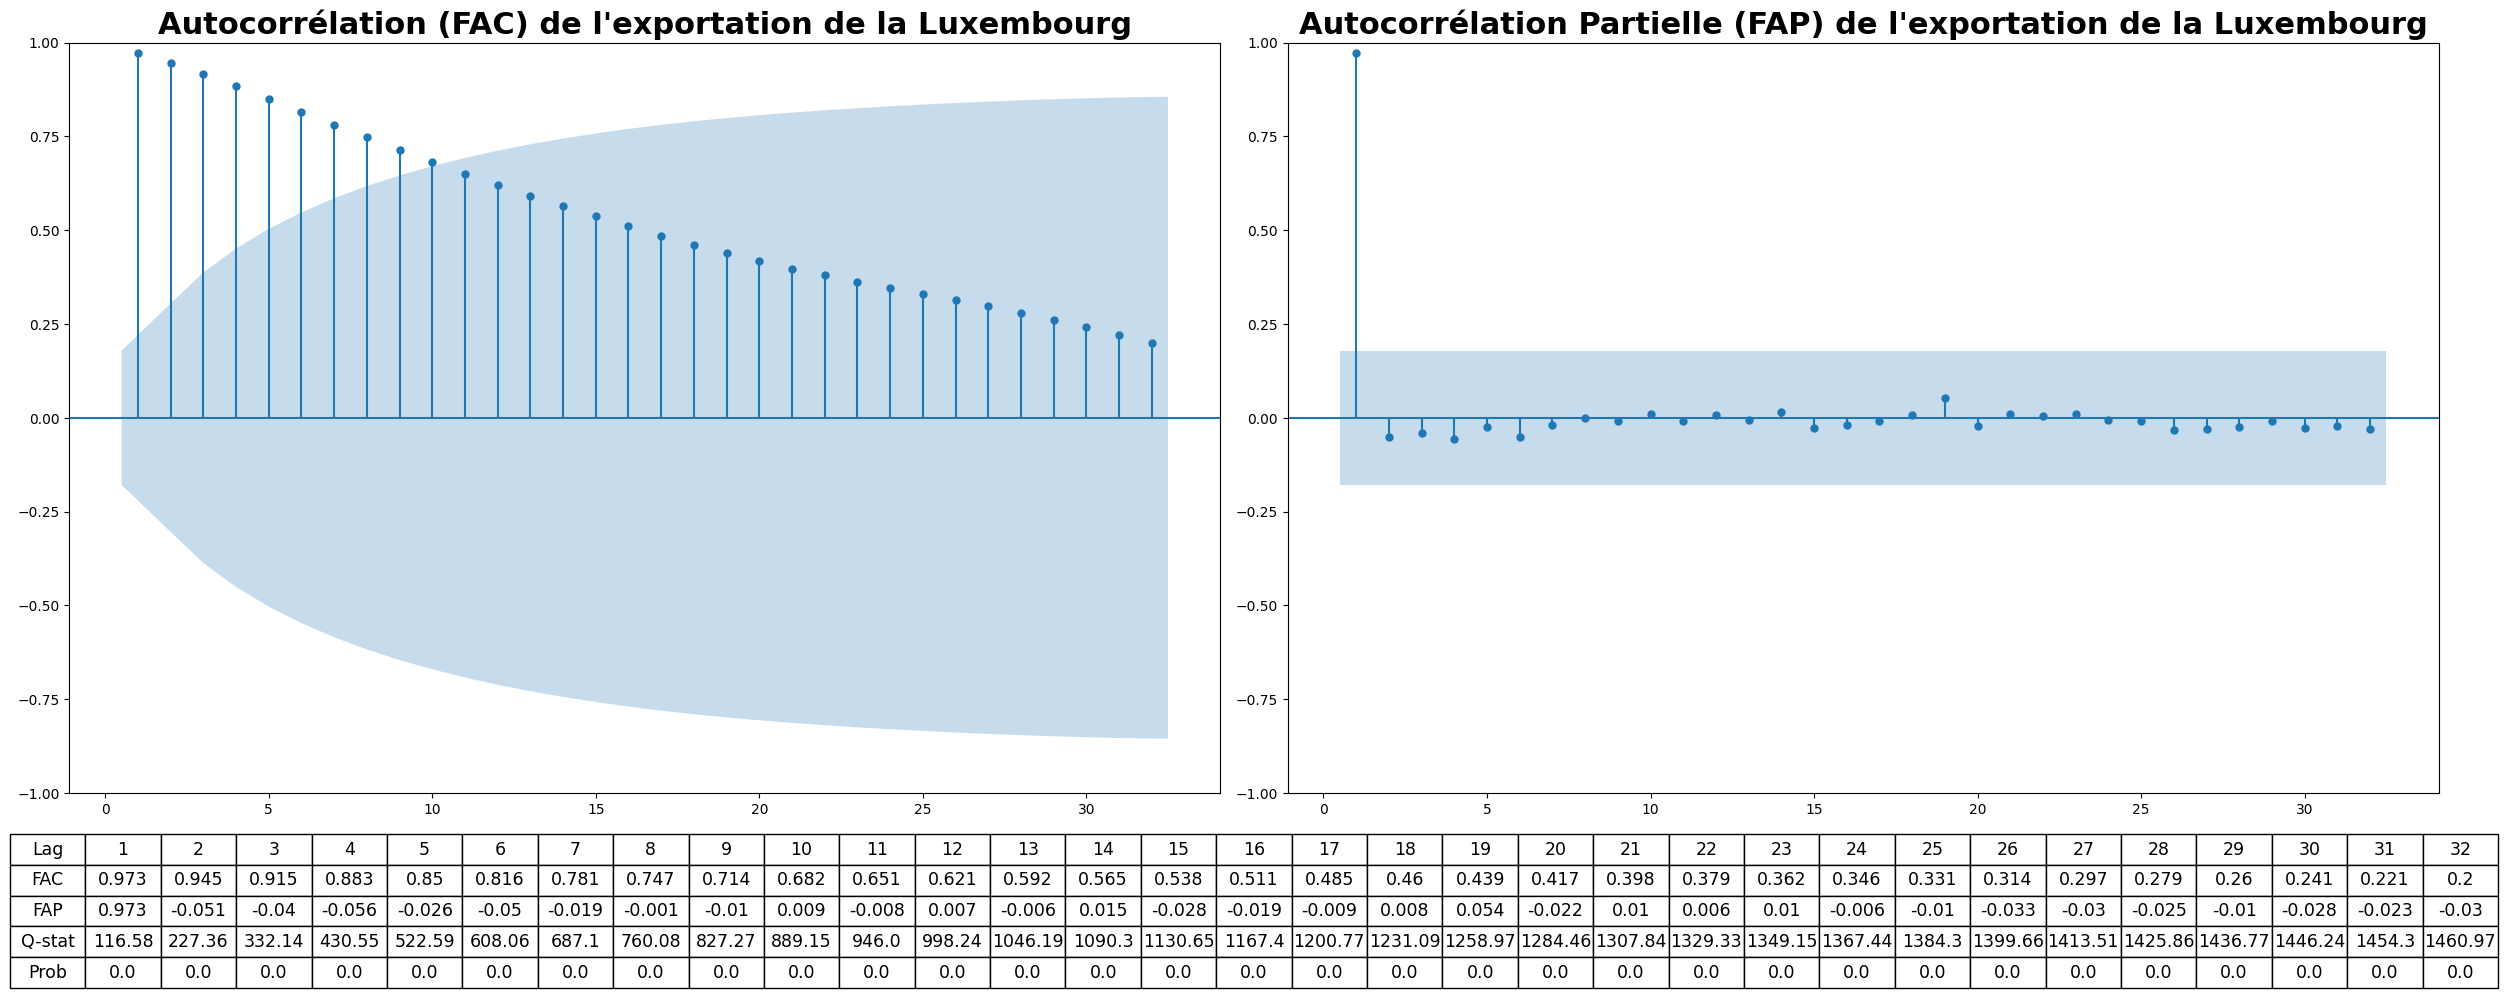

In [15]:
XG = XT.set_index("Lag").T
XG = XG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    X,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'exportation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    X,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=XG.values, colLabels=XG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
# plt.savefig('XGraph+Table.png', bbox_inches='tight')
plt.show()

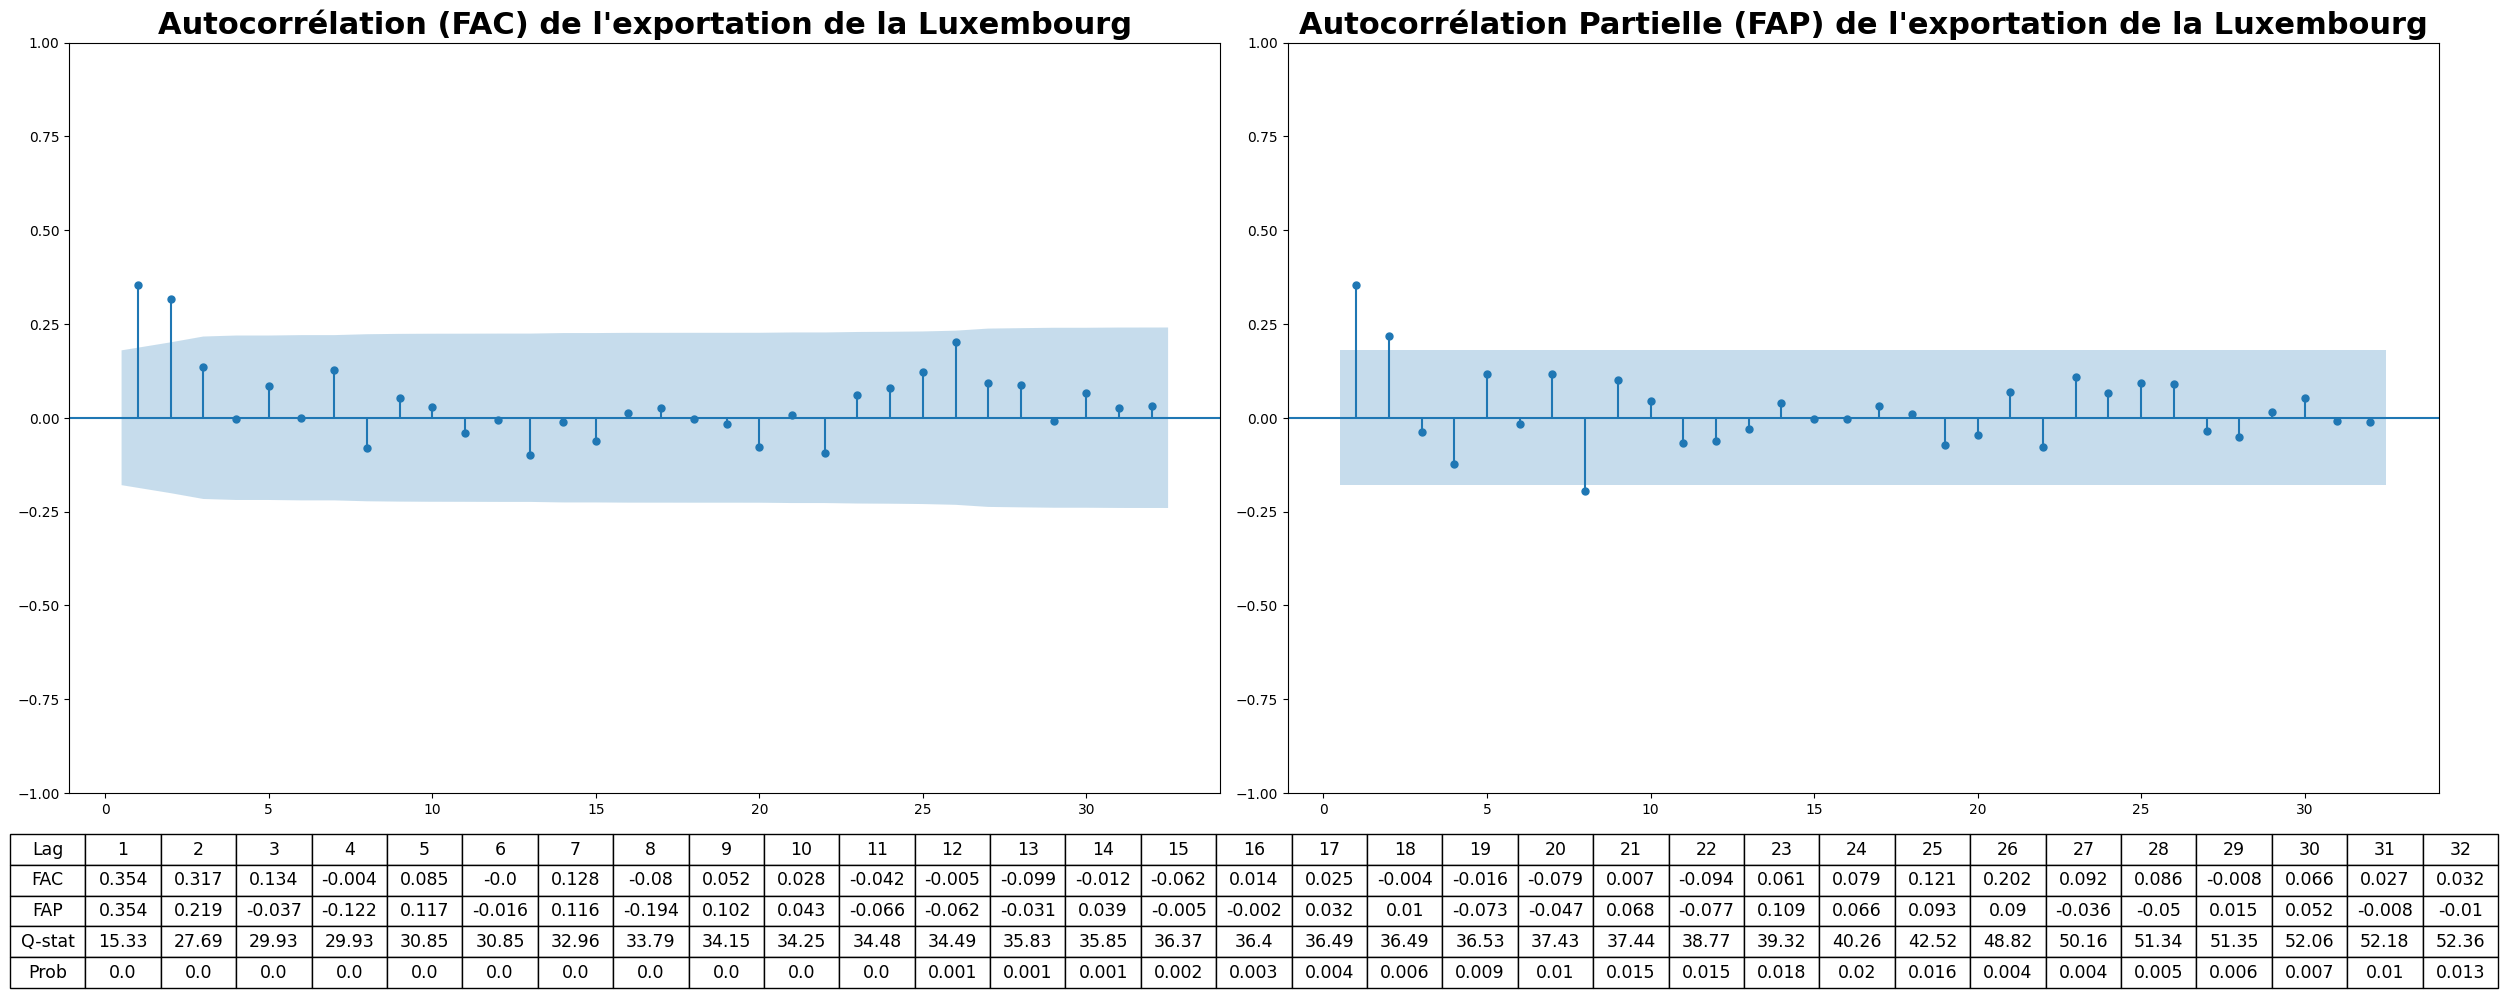

In [16]:
XDG = XTD.set_index("Lag").T
XDG = XDG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    X_diff,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'exportation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    X_diff,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=XDG.values, colLabels=XDG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
# plt.savefig('XDiffGraph+Table.png', bbox_inches='tight')
plt.show()

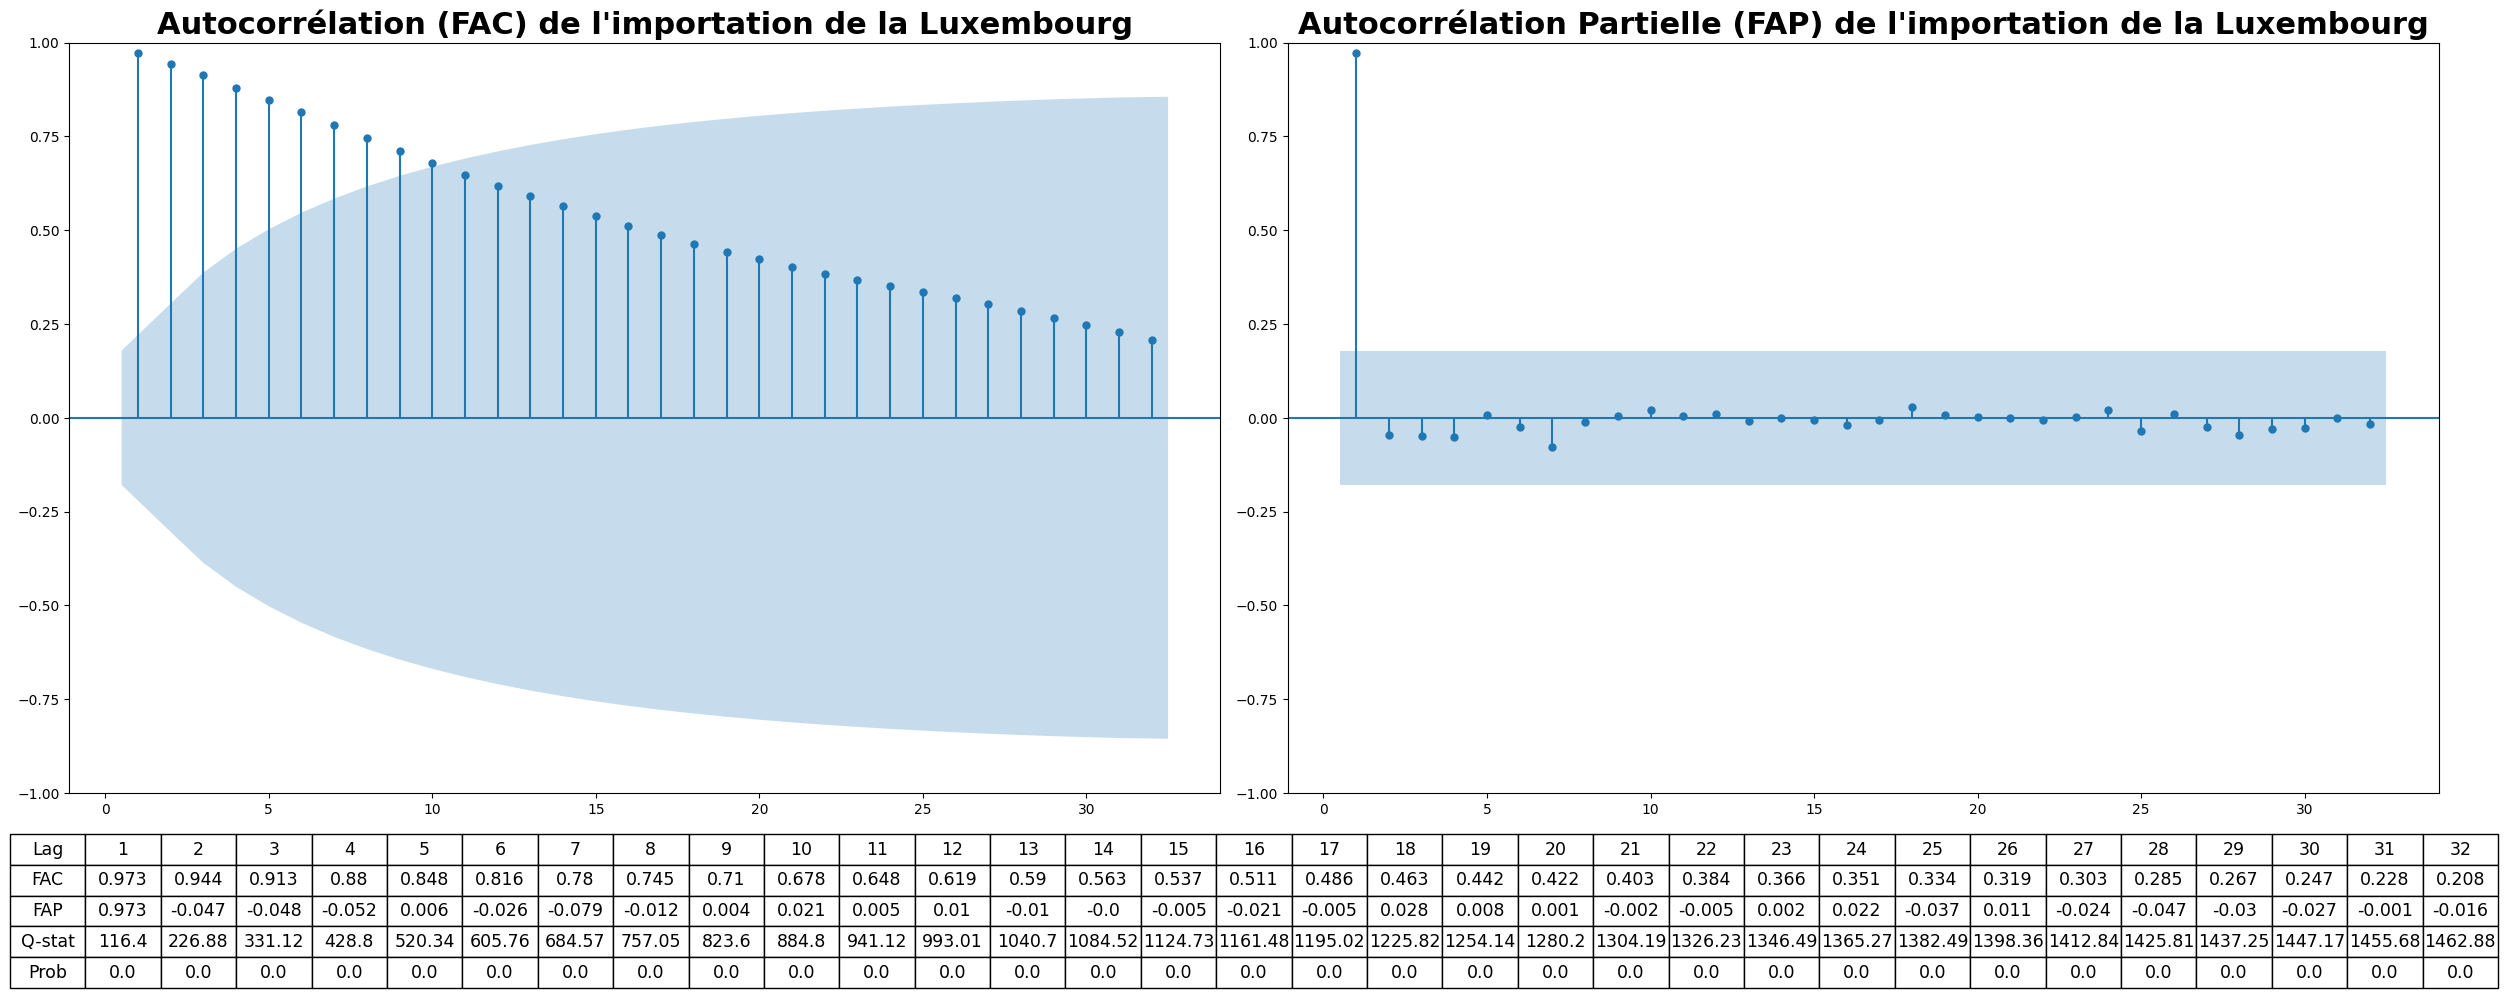

In [17]:
MG = MT.set_index("Lag").T
MG = MG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    M,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'importation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    M,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'importation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)

# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=MG.values, colLabels=MG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)
plt.tight_layout()
# plt.savefig('MGraph+Table.png', bbox_inches='tight')
plt.show()

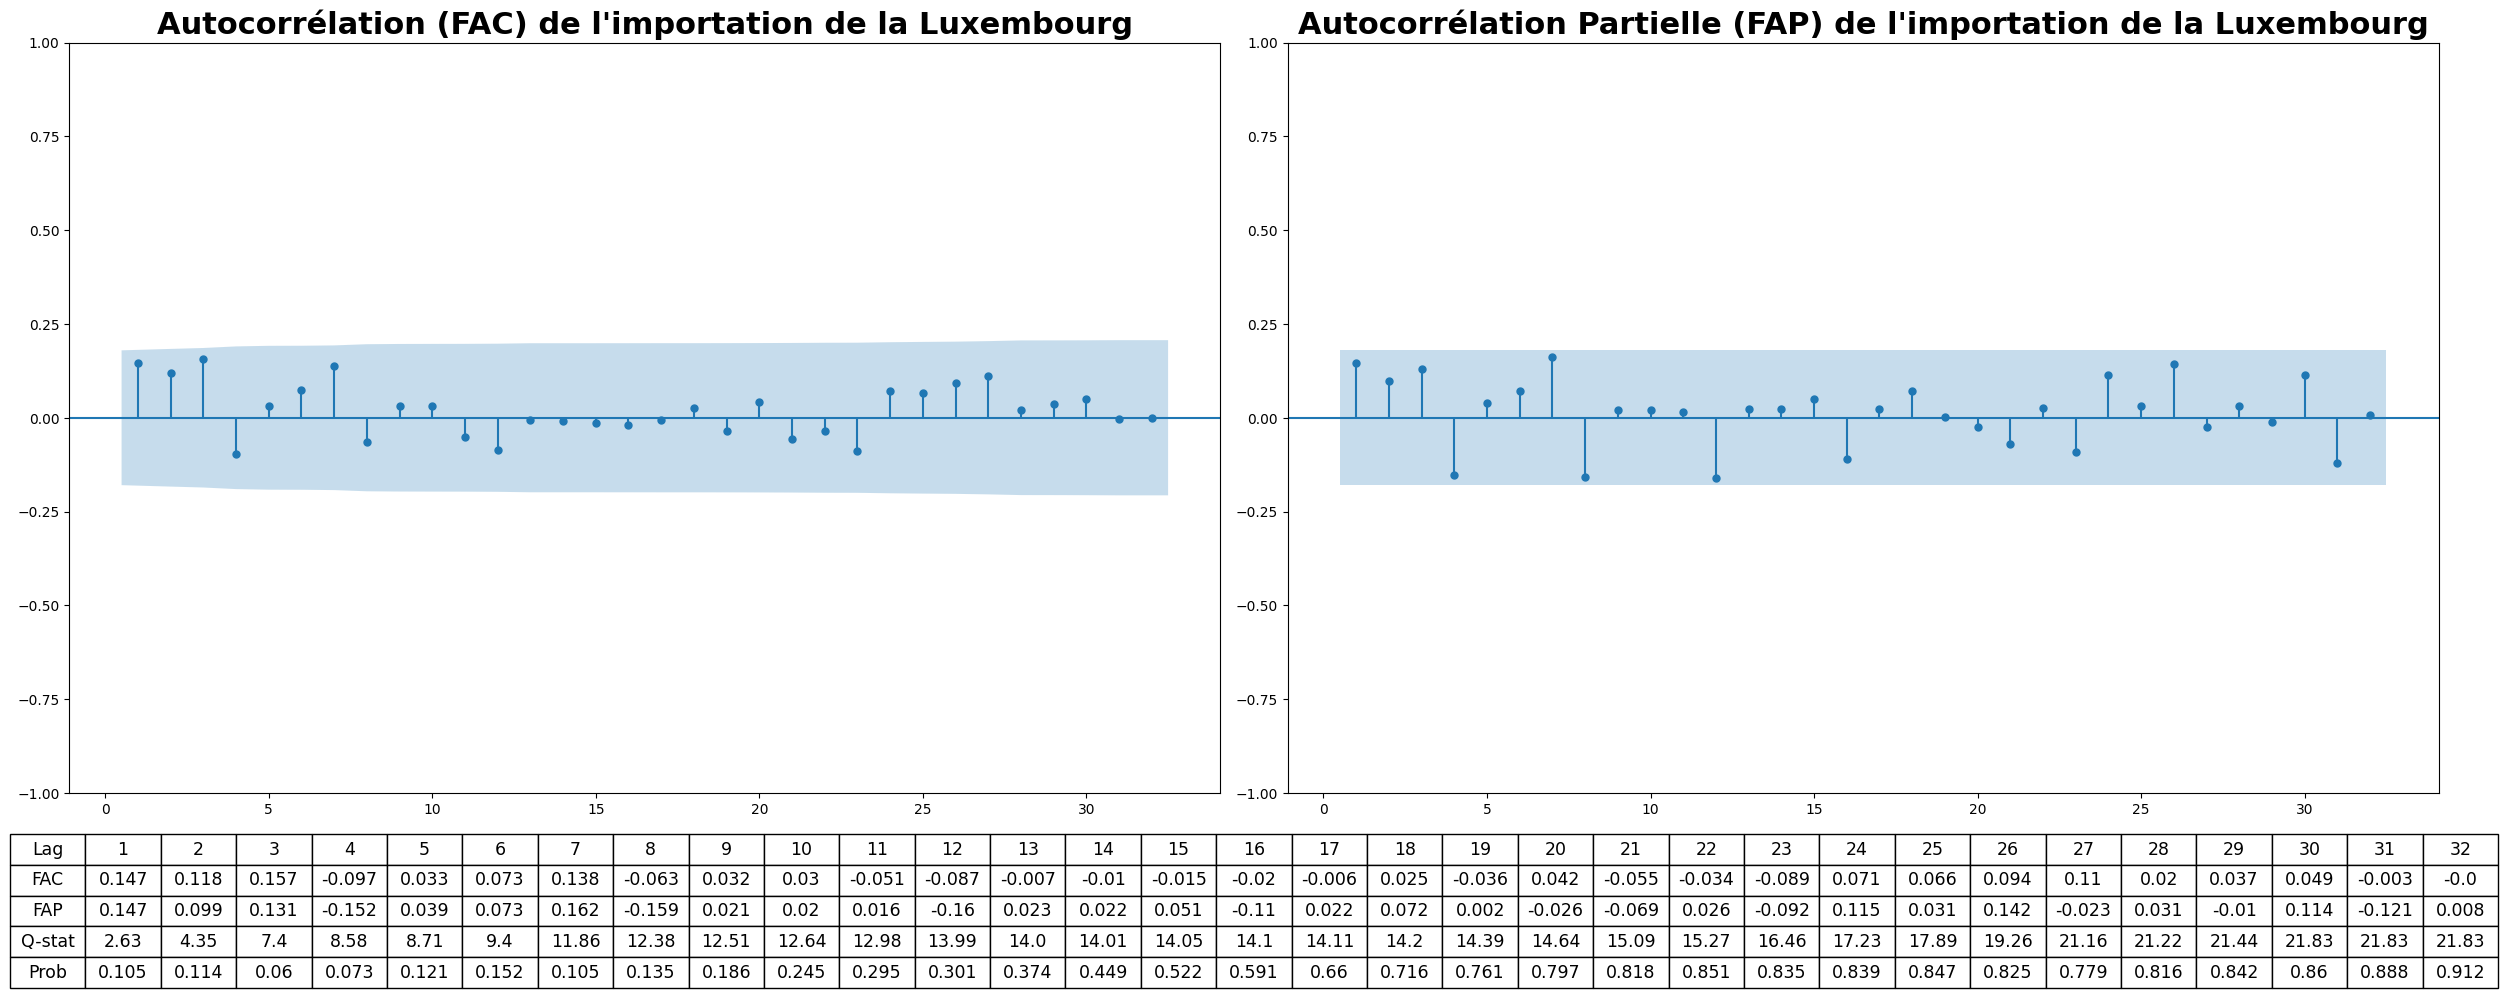

In [18]:
MDG = MTD.set_index("Lag").T
MDG = MDG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(
    M_diff,
    lags=32,
    zero=False,
    title="Autocorrélation (FAC) de l'exportation de la Luxembourg",
    ax=ax0,
)
ax0.set_title(
    "Autocorrélation (FAC) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)

ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(
    M_diff,
    lags=32,
    zero=False,
    title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg",
    ax=ax1,
)
ax1.set_title(
    "Autocorrélation Partielle (FAP) de l'importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas là
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=MDG.values, colLabels=MDG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
# plt.savefig('MDiffGraph+Table.png', bbox_inches='tight')
plt.show()

# PARTIE 2 : Modèle multivariée

## Causalité de Granger

In [19]:
XMD = XM.diff().fillna(0).rename(columns={"lnX": "ΔlnX", "lnM": "ΔlnM"})
VARXMD = VAR(XMD)

In [20]:
VARXMD_1 = VARXMD.fit(1)
VARXMD_1.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 27, Mar, 2026
Time:                     23:14:53
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -15.0877
Nobs:                     119.000    HQIC:                  -15.1709
Log likelihood:           574.347    FPE:                2.43587e-07
AIC:                     -15.2278    Det(Omega_mle):     2.31755e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.007529         0.002409            3.125           0.002
L1.ΔlnX         0.441736         0.129852            3.402           0.001
L1.ΔlnM        -0.086756         0.102140           -0.849           0.396

Results f

In [21]:
VARXMD_2 = VARXMD.fit(2)
VARXMD_2.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 27, Mar, 2026
Time:                     23:14:54
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -15.0909
Nobs:                     118.000    HQIC:                  -15.2304
Log likelihood:           579.348    FPE:                2.20887e-07
AIC:                     -15.3257    Det(Omega_mle):     2.03294e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.005139         0.002499            2.057           0.040
L1.ΔlnX         0.397956         0.128325            3.101           0.002
L1.ΔlnM        -0.126872         0.105749           -1.200           0.230
L2.ΔlnX   

In [22]:
VARXMD_3 = VARXMD.fit(3)
VARXMD_3.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 27, Mar, 2026
Time:                     23:14:54
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.9669
Nobs:                     117.000    HQIC:                  -15.1633
Log likelihood:           576.869    FPE:                2.27261e-07
AIC:                     -15.2975    Det(Omega_mle):     2.02327e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.005054         0.002629            1.923           0.055
L1.ΔlnX         0.387736         0.136012            2.851           0.004
L1.ΔlnM        -0.106732         0.112414           -0.949           0.342
L2.ΔlnX   

In [23]:
VARXMD_4 = VARXMD.fit(4)
VARXMD_4.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 27, Mar, 2026
Time:                     23:14:55
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.9114
Nobs:                     116.000    HQIC:                  -15.1652
Log likelihood:           578.447    FPE:                2.18165e-07
AIC:                     -15.3386    Det(Omega_mle):     1.87880e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.006337         0.002759            2.297           0.022
L1.ΔlnX         0.391169         0.139467            2.805           0.005
L1.ΔlnM        -0.103968         0.114962           -0.904           0.366
L2.ΔlnX   

In [24]:
VARXMD_2.test_causality("ΔlnX", ["ΔlnM"], kind="wald", signif=0.05).summary()

Test statistic,Critical value,p-value,df
2.813,5.991,0.245,2


In [25]:
VARXMD_2.test_causality("ΔlnX", ["ΔlnX"], kind="wald", signif=0.01).summary()

Test statistic,Critical value,p-value,df
10.99,9.210,0.004,2


In [26]:
VARXMD_2.test_causality("ΔlnM", ["ΔlnX"], kind="wald", signif=0.1).summary()

Test statistic,Critical value,p-value,df
36.04,4.605,0.000,2


In [27]:
VARXMD_2.test_causality("ΔlnM", ["ΔlnM"], kind="wald", signif=0.05).summary()

Test statistic,Critical value,p-value,df
13.67,5.991,0.001,2


In [28]:
GTXM = (
    VARXMD_2.test_causality("ΔlnX", ["ΔlnM"], kind="wald", signif=0.05)
    .summary()
    .as_text()
)
GTXX = (
    VARXMD_2.test_causality("ΔlnX", ["ΔlnX"], kind="wald", signif=0.01)
    .summary()
    .as_text()
)
GTMX = (
    VARXMD_2.test_causality("ΔlnM", ["ΔlnX"], kind="wald", signif=0.1)
    .summary()
    .as_text()
)
GTMM = (
    VARXMD_2.test_causality("ΔlnM", ["ΔlnM"], kind="wald", signif=0.05)
    .summary()
    .as_text()
)
GTALL = {"GTXM", "GTXX", "GTMX", "GTMM"}
GTTEXT = "TestGranger_{}.txt"

for n in GTALL:
    # Obtenez le contenu de la variable
    content = globals()[n]
    with open(GTTEXT.format(n), "w") as file:
        file.write(f"{content}\n")

In [29]:
Test = grangercausalitytests(XMD, 2, addconst=True, verbose=None)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.7215  , p=0.3974  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=0.7401  , p=0.3896  , df=1
likelihood ratio test: chi2=0.7378  , p=0.3904  , df=1
parameter F test:         F=0.7215  , p=0.3974  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.4065  , p=0.2493  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=2.9374  , p=0.2302  , df=2
likelihood ratio test: chi2=2.9014  , p=0.2344  , df=2
parameter F test:         F=1.4065  , p=0.2493  , df_denom=113, df_num=2


# PARTIE 3 : Cointégration

### MCO de la régression des exportations sur les  importations

In [30]:
x2 = sm.add_constant(M["M"])
y2 = X["X"]

modelXM = sm.OLS(y2, x2).fit()
print(modelXM.summary())
with open("modelXM.txt", "w") as f:
    f.write(modelXM.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                      X   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.122e+04
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          5.56e-152
Time:                        23:15:02   Log-Likelihood:                 280.64
No. Observations:                 120   AIC:                            -557.3
Df Residuals:                     118   BIC:                            -551.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8472      0.044     19.431      0.0

### Résidu du MCO Exp sur Imp

In [31]:
Residuxm = modelXM.resid

ResiduXM = pd.DataFrame({"Valeurs_ajustées": modelXM.fittedvalues, "u": Residuxm})

### MCO de la régression des importations sur les exportations

In [32]:
x1 = sm.add_constant(X["X"])
y1 = M["M"]

modelMX = sm.OLS(y1, x1).fit()
print(modelMX.summary())
with open("modelMX.txt", "w") as f:
    f.write(modelMX.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                      M   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.122e+04
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          5.56e-152
Time:                        23:15:05   Log-Likelihood:                 272.41
No. Observations:                 120   AIC:                            -540.8
Df Residuals:                     118   BIC:                            -535.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8790      0.051    -17.206      0.0

### Résidu du MCO Imp sur Exp

In [33]:
Residumx = modelMX.resid

ResiduMX = pd.DataFrame({"Valeurs_ajustées": modelMX.fittedvalues, "u": Residumx})

### Graphique des résidus

In [34]:
ResiduXMG = ResiduXM.drop("Valeurs_ajustées", axis=1)
ResiduXMGFlat = np.array(ResiduXMG).flatten()

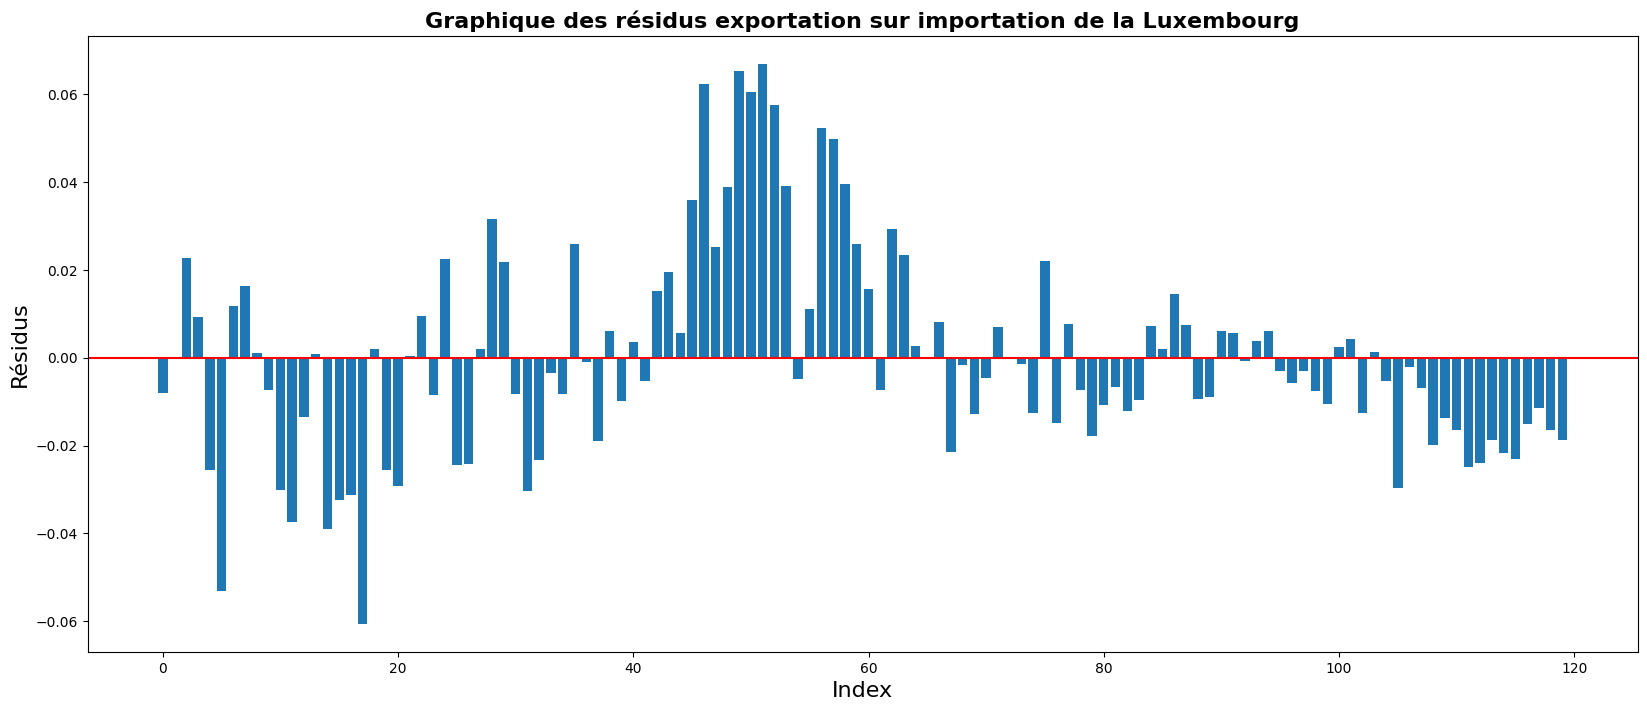

In [35]:
plt.figure(figsize=(20, 8))
plt.bar(range(len(ResiduXMGFlat)), ResiduXMGFlat)
plt.axhline(y=0, color="r", linestyle="-")
plt.xlabel("Index", fontsize=16)
plt.ylabel("Résidus", fontsize=16)
plt.title(
    "Graphique des résidus exportation sur importation de la Luxembourg",
    fontsize=16,
    fontweight="bold",
)
plt.savefig("GraphRésXM.png", bbox_inches="tight")

In [36]:
ResiduMXG = ResiduMX.drop("Valeurs_ajustées", axis=1)
ResiduMXGFlat = np.array(ResiduMXG).flatten()

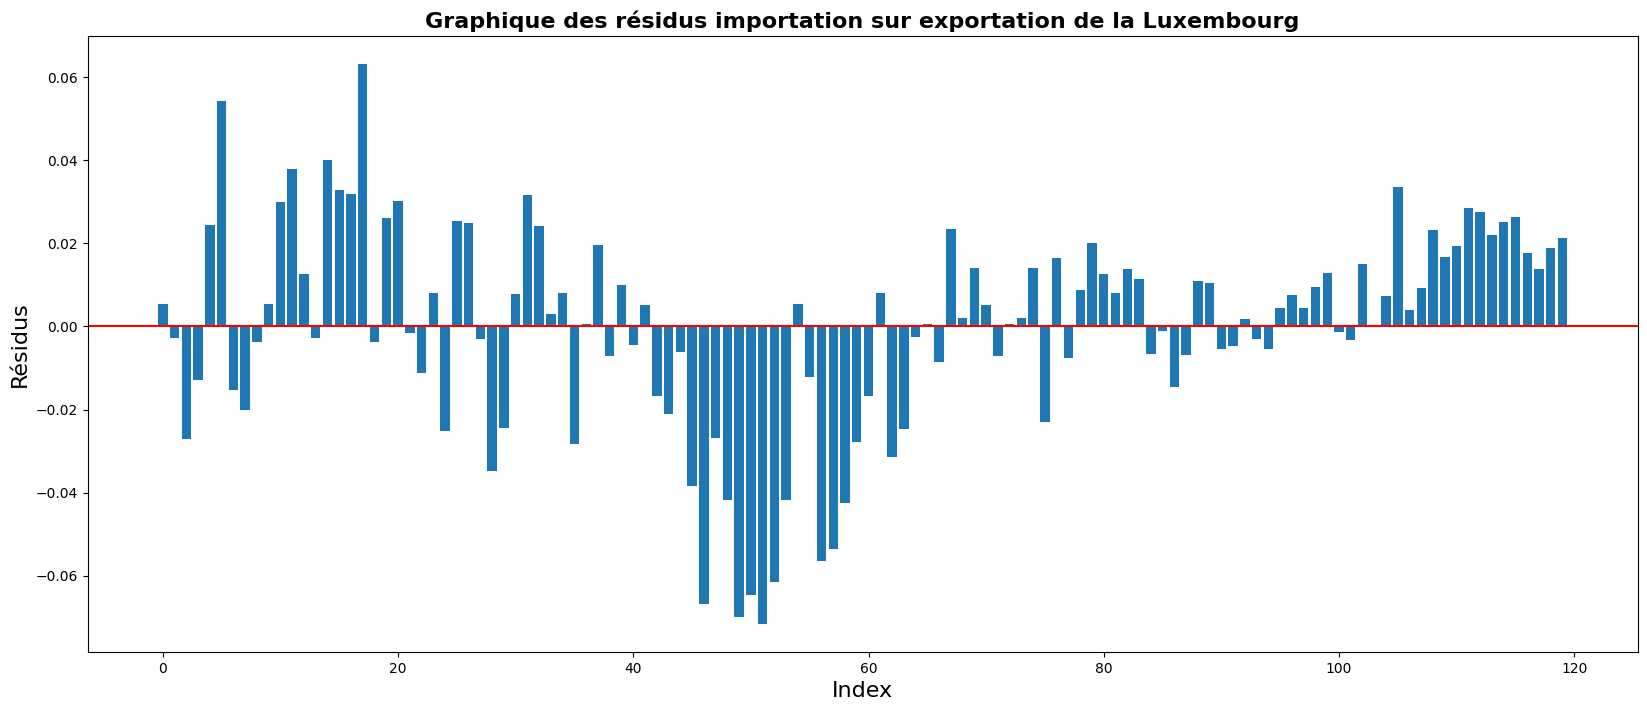

In [37]:
plt.figure(figsize=(20, 8))
plt.bar(range(len(ResiduMXGFlat)), ResiduMXGFlat)
plt.axhline(y=0, color="r", linestyle="-")
plt.xlabel("Index", fontsize=16)
plt.ylabel("Résidus", fontsize=16)
plt.title(
    "Graphique des résidus importation sur exportation de la Luxembourg",
    fontsize=16,
    fontweight="bold",
)
plt.savefig("GraphRésMX.png", bbox_inches="tight")

### Tableau résidu

In [38]:
TRXM = ResiduXMG.rename(columns={"u": "uXM"})
TRMX = ResiduMXG.rename(columns={"u": "uMX"})
TableauRésXM = TRXM.join(TRMX)

In [39]:
TableauRésXM.to_csv("TableauRésXM.csv", index=True)

with open("TableauRésXM.txt", "a") as f:
    f.write(TableauRésXM.to_string(header=False, index=False))

### FAC et FAP des résidus ΔuXM et ΔuMX

In [40]:
ΔuXM_fac = acf(
    ResiduXMG,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
ΔuXMT = pd.DataFrame(ΔuXM_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
ΔuXM_fap = pacf(ResiduXMG, nlags=32, method="ywmle", alpha=None)
ΔuXTFAP = (
    pd.DataFrame(ΔuXM_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
ΔuXMT.insert(1, "FAP", ΔuXTFAP)
ΔuXMT.iloc[:, 0] = ΔuXMT.iloc[:, 0].shift(-1)
ΔuXMT = ΔuXMT.drop(ΔuXMT.index[-1]).reset_index(drop=True)

ΔuXMT[["FAC", "FAP", "Prob"]] = ΔuXMT[["FAC", "FAP", "Prob"]].round(3)

ΔuXMT[["Q-stat"]] = ΔuXMT[["Q-stat"]].round(2)

ΔuXMT.insert(0, "Lag", range(1, len(ΔuXMT) + 1))

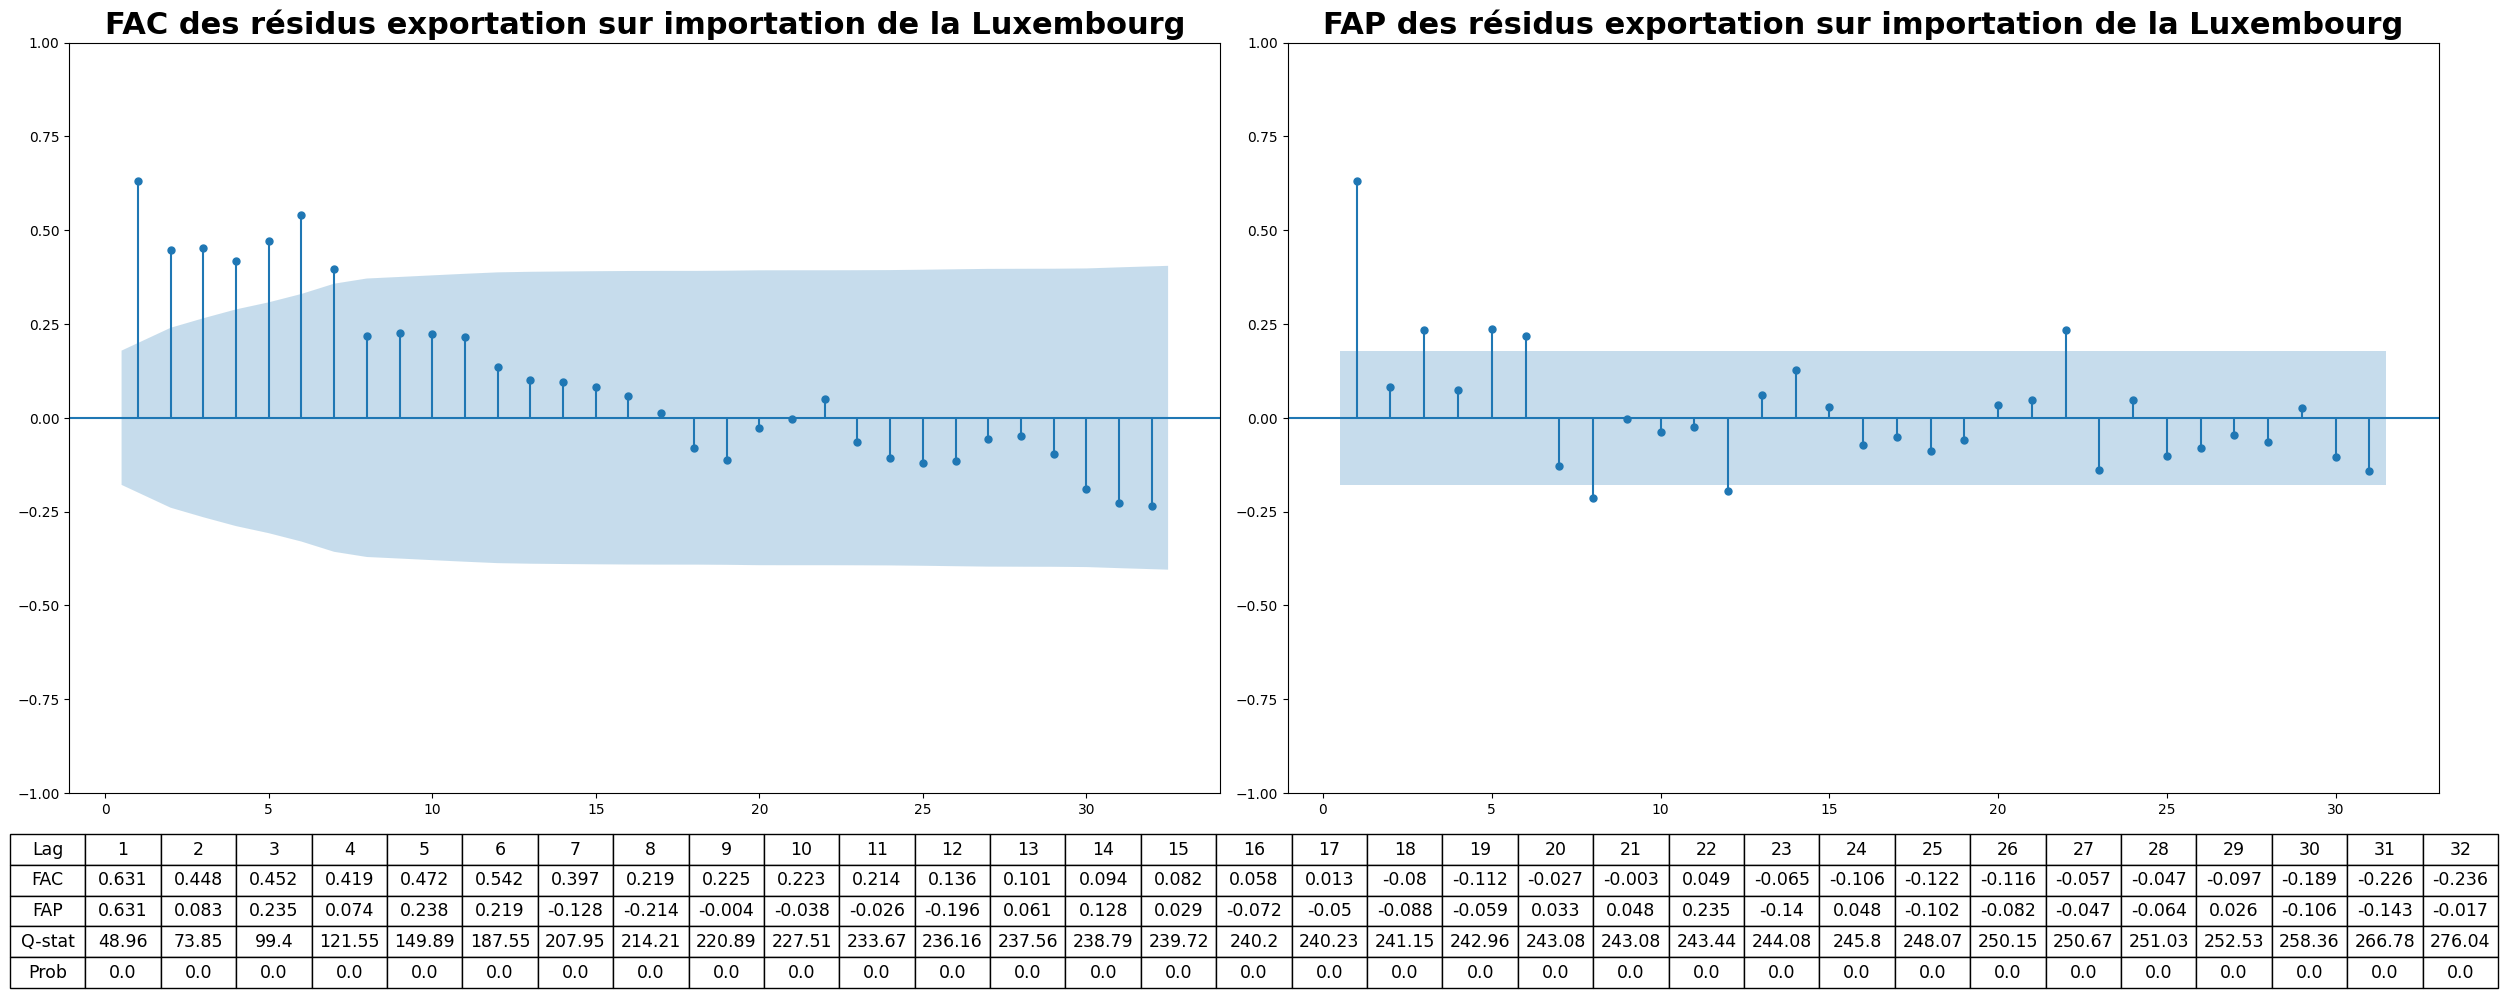

In [41]:
XG = ΔuXMT.set_index("Lag").T
XG = XG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(ResiduXMG, lags=32, zero=False, ax=ax0)
ax0.set_title(
    "FAC des résidus exportation sur importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(ResiduXMG, lags=31, zero=False, ax=ax1)
ax1.set_title(
    "FAP des résidus exportation sur importation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=XG.values, colLabels=XG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
plt.savefig("ΔuXMTGraph+Table.png", bbox_inches="tight")
plt.show()

In [42]:
ΔuMX_fac = acf(
    ResiduMXG,
    adjusted=0,
    nlags=32,
    qstat=True,
    fft=True,
    alpha=None,
    bartlett_confint=True,
    missing="none",
)
ΔuMXT = pd.DataFrame(ΔuMX_fac).T.rename(columns={0: "FAC", 1: "Q-stat", 2: "Prob"})
ΔuMX_fap = pacf(ResiduMXG, nlags=32, method="ywmle", alpha=None)
ΔuMXTFAP = (
    pd.DataFrame(ΔuMX_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0: "FAP"})
)
ΔuMXT.insert(1, "FAP", ΔuMXTFAP)
ΔuMXT.iloc[:, 0] = ΔuMXT.iloc[:, 0].shift(-1)
ΔuMXT = ΔuMXT.drop(ΔuMXT.index[-1]).reset_index(drop=True)

ΔuMXT[["FAC", "FAP", "Prob"]] = ΔuMXT[["FAC", "FAP", "Prob"]].round(3)

ΔuMXT[["Q-stat"]] = ΔuMXT[["Q-stat"]].round(2)

ΔuMXT.insert(0, "Lag", range(1, len(ΔuMXT) + 1))

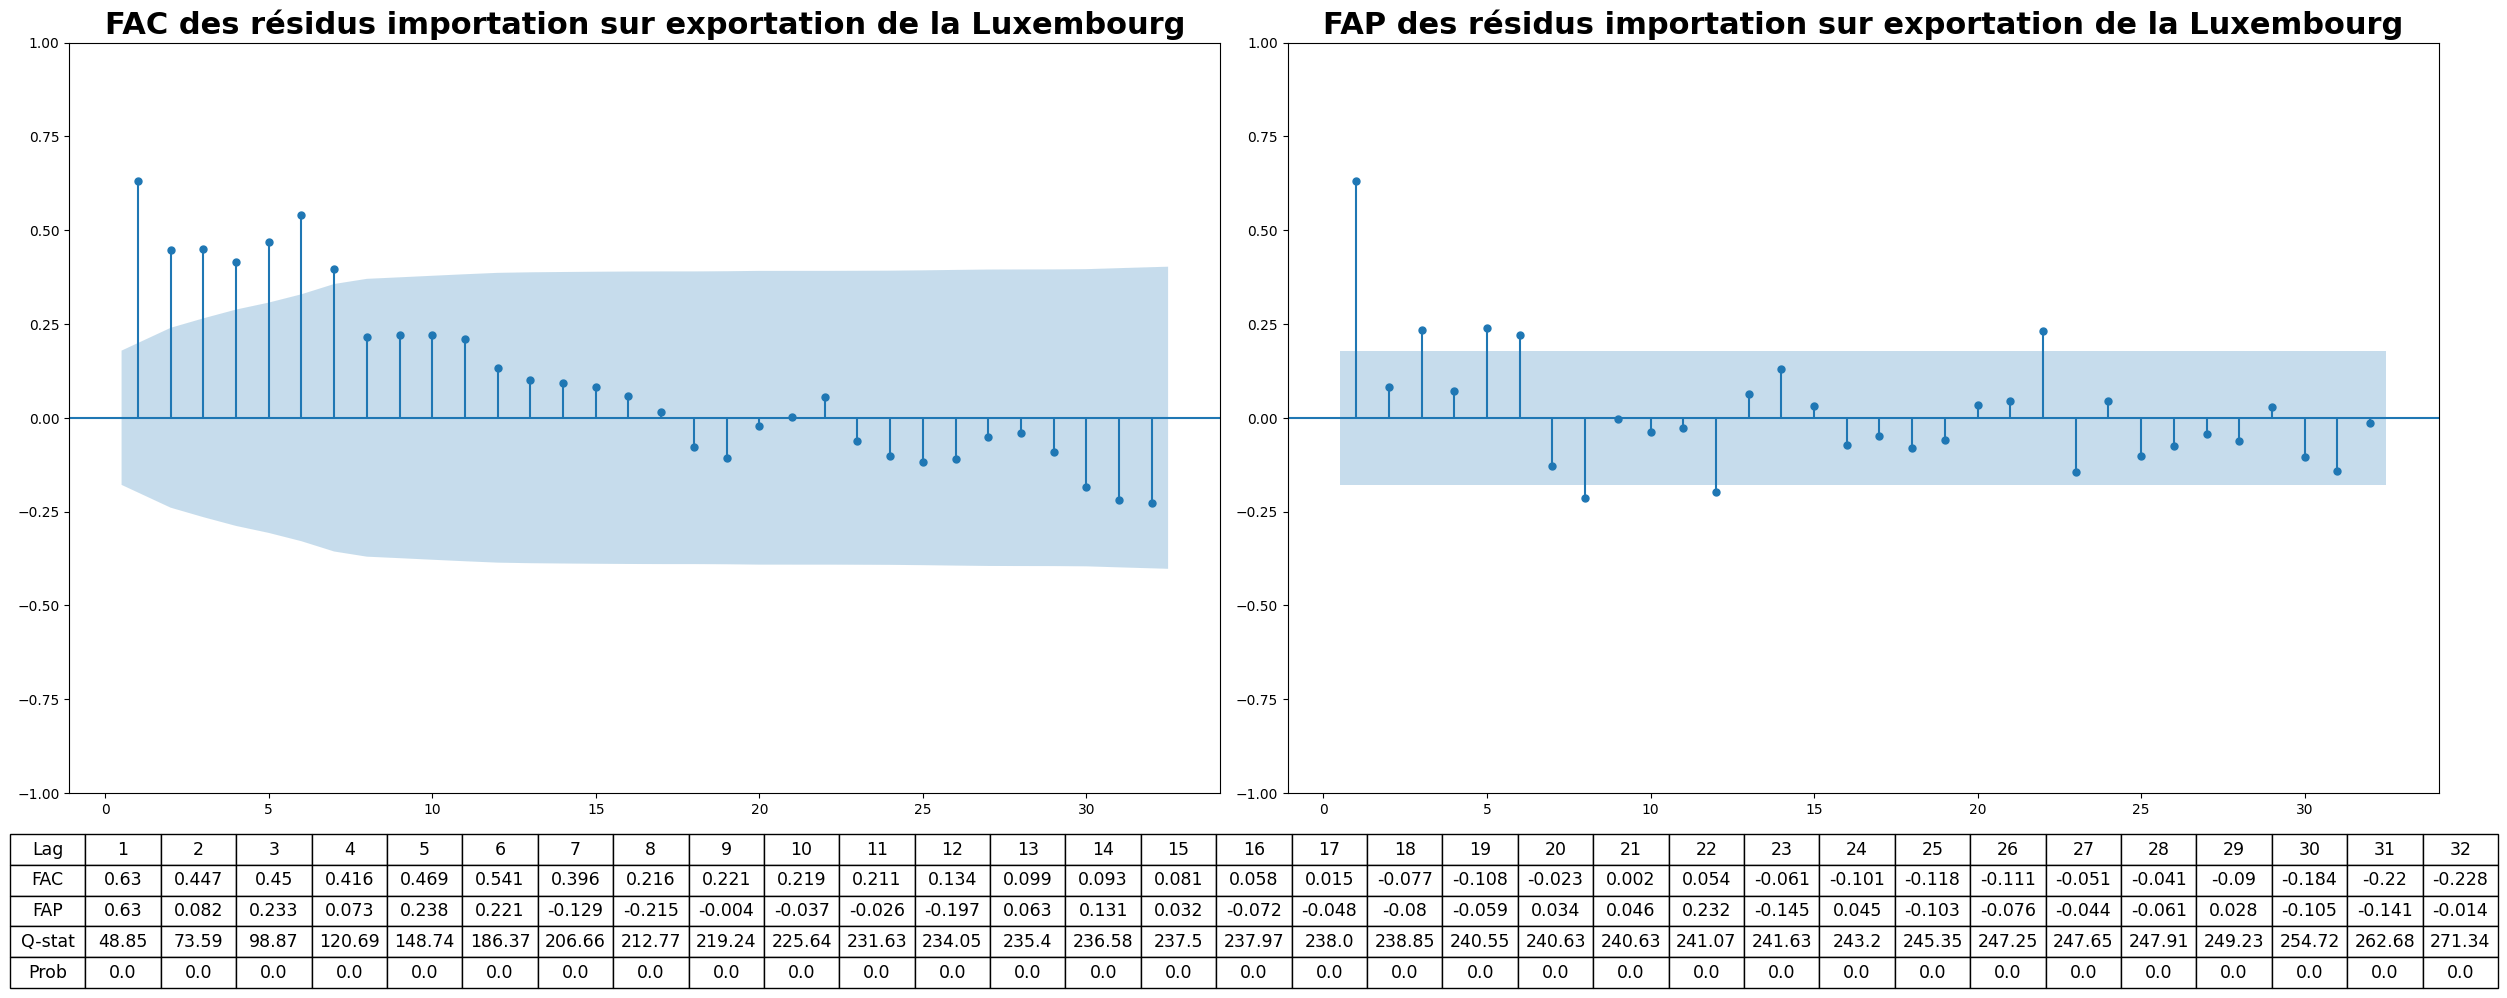

In [43]:
MG = ΔuMXT.set_index("Lag").T
MG = MG.reset_index().rename(
    columns={"index": "Lag"}
)  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(ResiduMXG, lags=32, zero=False, ax=ax0)
ax0.set_title(
    "FAC des résidus importation sur exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(ResiduMXG, lags=32, zero=False, ax=ax1)
ax1.set_title(
    "FAP des résidus importation sur exportation de la Luxembourg",
    fontsize=22,
    fontweight="bold",
)

# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(
    cellText=MG.values, colLabels=MG.columns, cellLoc="center", loc="upper center"
)
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)
plt.tight_layout()
plt.savefig("ΔuMXTGraph+Table.png", bbox_inches="tight")
plt.show()

### Regréssions

In [44]:
def retard(df, column_name, n):
    """
    Applique des décalages à une colonne d'un DataFrame et ajoute les colonnes décalées.

    :param df: DataFrame pandas
    :param column_name: Nom de la colonne à décaler
    :param n: Nombre de décalages à appliquer
    :return: DataFrame avec les colonnes décalées ajoutées
    """
    for i in range(1, n + 1):
        df[f"{column_name}(-{i})"] = df[column_name].shift(i, fill_value=0)
    return df

In [45]:
ResiduXM_D = ResiduXM.drop("Valeurs_ajustées", axis=1)
ResiduXM_D = ResiduXM_D.diff().fillna(0).rename(columns={"u": "Δu"})
ResiduXM_D = retard(ResiduXM_D, "Δu", 4)
ResiduXM_R = (
    ResiduXM.shift(fill_value=0)
    .rename(columns={"u": "u(-1)"})
    .drop("Valeurs_ajustées", axis=1)
)
ResiduXM_M = ResiduXM_R.join(ResiduXM_D, how="left").rename(columns={"Δu": "ΔuXM"})
print(ResiduXM_M)

            u(-1)      ΔuXM    Δu(-1)    Δu(-2)    Δu(-3)    Δu(-4)
1995-Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1995-Q2 -0.007940  0.007869  0.000000  0.000000  0.000000  0.000000
1995-Q3 -0.000071  0.022680  0.007869  0.000000  0.000000  0.000000
1995-Q4  0.022609 -0.013271  0.022680  0.007869  0.000000  0.000000
1996-Q1  0.009338 -0.034829 -0.013271  0.022680  0.007869  0.000000
...           ...       ...       ...       ...       ...       ...
2023-Q4 -0.021726 -0.001265 -0.003009  0.005276  0.000919 -0.008553
2024-Q1 -0.022990  0.007955 -0.001265 -0.003009  0.005276  0.000919
2024-Q2 -0.015035  0.003519  0.007955 -0.001265 -0.003009  0.005276
2024-Q3 -0.011516 -0.004976  0.003519  0.007955 -0.001265 -0.003009
2024-Q4 -0.016492 -0.002158 -0.004976  0.003519  0.007955 -0.001265

[120 rows x 6 columns]


In [46]:
ResiduMX_D = ResiduMX.drop("Valeurs_ajustées", axis=1)
ResiduMX_D = ResiduMX_D.diff().fillna(0).rename(columns={"u": "Δu"})
ResiduMX_D = retard(ResiduMX_D, "Δu", 4)
ResiduMX_R = (
    ResiduMX.shift(fill_value=0)
    .rename(columns={"u": "u(-1)"})
    .drop("Valeurs_ajustées", axis=1)
)
ResiduMX_M = ResiduMX_R.join(ResiduMX_D, how="left").rename(columns={"Δu": "ΔuMX"})
print(ResiduMX_M)

            u(-1)      ΔuMX    Δu(-1)    Δu(-2)    Δu(-3)    Δu(-4)
1995-Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1995-Q2  0.005517 -0.008416  0.000000  0.000000  0.000000  0.000000
1995-Q3 -0.002899 -0.024226 -0.008416  0.000000  0.000000  0.000000
1995-Q4 -0.027125  0.014208 -0.024226 -0.008416  0.000000  0.000000
1996-Q1 -0.012917  0.037420  0.014208 -0.024226 -0.008416  0.000000
...           ...       ...       ...       ...       ...       ...
2023-Q4  0.025143  0.001238  0.003233 -0.005666 -0.000973  0.009209
2024-Q1  0.026380 -0.008661  0.001238  0.003233 -0.005666 -0.000973
2024-Q2  0.017719 -0.003881 -0.008661  0.001238  0.003233 -0.005666
2024-Q3  0.013838  0.005164 -0.003881 -0.008661  0.001238  0.003233
2024-Q4  0.019003  0.002247  0.005164 -0.003881 -0.008661  0.001238

[120 rows x 6 columns]


## Nombre de retard à prendre pour la VECM

### Exportation sur Importation XM

In [47]:
XMy = ResiduXM_M["ΔuXM"]

In [48]:
XMx4 = ResiduXM_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)", "Δu(-4)"]]
XMx4 = sm.add_constant(XMx4)

modelXM4 = sm.OLS(XMy, XMx4).fit()

In [49]:
XMx3 = ResiduXM_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)"]]
XMx3 = sm.add_constant(XMx3)

modelXM3 = sm.OLS(XMy, XMx3).fit()

In [50]:
XMx2 = ResiduXM_M[["u(-1)", "Δu(-1)", "Δu(-2)"]]
XMx2 = sm.add_constant(XMx2)

modelXM2 = sm.OLS(XMy, XMx2).fit()

In [51]:
XMx1 = ResiduXM_M[["u(-1)", "Δu(-1)"]]
XMx1 = sm.add_constant(XMx1)

modelXM1 = sm.OLS(XMy, XMx1).fit()

In [52]:
XMx0 = ResiduXM_M[["u(-1)"]]
XMx0 = sm.add_constant(XMx0)

modelXM0 = sm.OLS(XMy, XMx0).fit()

### Importation sur Exportation MX

In [53]:
MXy = ResiduMX_M["ΔuMX"]

In [54]:
MXx4 = ResiduMX_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)", "Δu(-4)"]]
MXx4 = sm.add_constant(MXx4)

modelMX4 = sm.OLS(MXy, MXx4).fit()

In [55]:
MXx3 = ResiduMX_M[["u(-1)", "Δu(-1)", "Δu(-2)", "Δu(-3)"]]
MXx3 = sm.add_constant(MXx3)

modelMX3 = sm.OLS(MXy, MXx3).fit()

In [56]:
MXx2 = ResiduMX_M[["u(-1)", "Δu(-1)", "Δu(-2)"]]
MXx2 = sm.add_constant(MXx2)

modelMX2 = sm.OLS(MXy, MXx2).fit()

In [57]:
MXx1 = ResiduMX_M[["u(-1)", "Δu(-1)"]]
MXx1 = sm.add_constant(MXx1)

modelMX1 = sm.OLS(MXy, MXx1).fit()

In [58]:
MXx0 = ResiduMX_M[["u(-1)"]]
MXx0 = sm.add_constant(MXx0)

modelMX0 = sm.OLS(MXy, MXx0).fit()

In [59]:
for i in range(5):
    model_name = f"modelXM{i}"
    file_name = f"{model_name}.txt"
    current_model = globals()[model_name]
    text = current_model.summary().as_text()
    with open(file_name, "w") as file:
        file.write(text)

    print(f"Le modèle {model_name} a été sauvegardé dans {file_name}")

Le modèle modelXM0 a été sauvegardé dans modelXM0.txt
Le modèle modelXM1 a été sauvegardé dans modelXM1.txt
Le modèle modelXM2 a été sauvegardé dans modelXM2.txt
Le modèle modelXM3 a été sauvegardé dans modelXM3.txt
Le modèle modelXM4 a été sauvegardé dans modelXM4.txt


In [60]:
for i in range(5):
    model_name = f"modelMX{i}"
    file_name = f"{model_name}.txt"
    current_model = globals()[model_name]
    text = current_model.summary().as_text()
    with open(file_name, "w") as file:
        file.write(text)

    print(f"Le modèle {model_name} a été sauvegardé dans {file_name}")

Le modèle modelMX0 a été sauvegardé dans modelMX0.txt
Le modèle modelMX1 a été sauvegardé dans modelMX1.txt
Le modèle modelMX2 a été sauvegardé dans modelMX2.txt
Le modèle modelMX3 a été sauvegardé dans modelMX3.txt
Le modèle modelMX4 a été sauvegardé dans modelMX4.txt


In [61]:
from statsmodels.tsa.vector_ar.vecm import VECM

serie = pd.concat([X, M], axis=1)
serie.columns = ["logX", "logM"]

vecm = VECM(serie, k_ar_diff=2, coint_rank=1, deterministic="co")
vecm_res = vecm.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation logX
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1968      0.099      1.989      0.047       0.003       0.391
L1.logX        0.4910      0.133      3.688      0.000       0.230       0.752
L1.logM       -0.2325      0.116     -1.998      0.046      -0.461      -0.004
L2.logX        0.2529      0.141      1.790      0.073      -0.024       0.530
L2.logM        0.0094      0.107      0.087      0.930      -0.201       0.220
Det. terms outside the coint. relation & lagged endog. parameters for equation logM
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0313      0.122     -0.256      0.798      -0.271       0.208
L1.logX        0.8079      0.164      4.91

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [62]:
text = vecm_res.summary().as_text()
with open("vecm.txt", "w") as file:
    file.write(text)

## Partie 4

### Prévision

In [63]:
model = VECM(serie, k_ar_diff=2, coint_rank=1, deterministic="co")
model_fit = model.fit()

# Get the last `k_ar` observations (model's lag order)
lag_order = model.k_ar_diff
last_obs = serie.values[-lag_order:]


forecast = vecm_res.predict(steps=8)


forecast_df = pd.DataFrame(forecast, columns=serie.columns)

print(forecast_df)

        logX      logM
0  10.081391  9.918363
1  10.080525  9.915220
2  10.083682  9.918944
3  10.090493  9.925333
4  10.099377  9.934047
5  10.109516  9.944703
6  10.120295  9.956067
7  10.131491  9.967853


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [64]:
# Formater le dataframe forecast_df comme serie

# Générer la liste des nouveaux labels
quarters = [f"{year}-Q{quarter}" for year in [2025, 2026] for quarter in range(1, 5)]

# Affecter cette liste comme nouvel index
forecast_df.index = quarters

# Vérifier le résultat
print(forecast_df)

              logX      logM
2025-Q1  10.081391  9.918363
2025-Q2  10.080525  9.915220
2025-Q3  10.083682  9.918944
2025-Q4  10.090493  9.925333
2026-Q1  10.099377  9.934047
2026-Q2  10.109516  9.944703
2026-Q3  10.120295  9.956067
2026-Q4  10.131491  9.967853


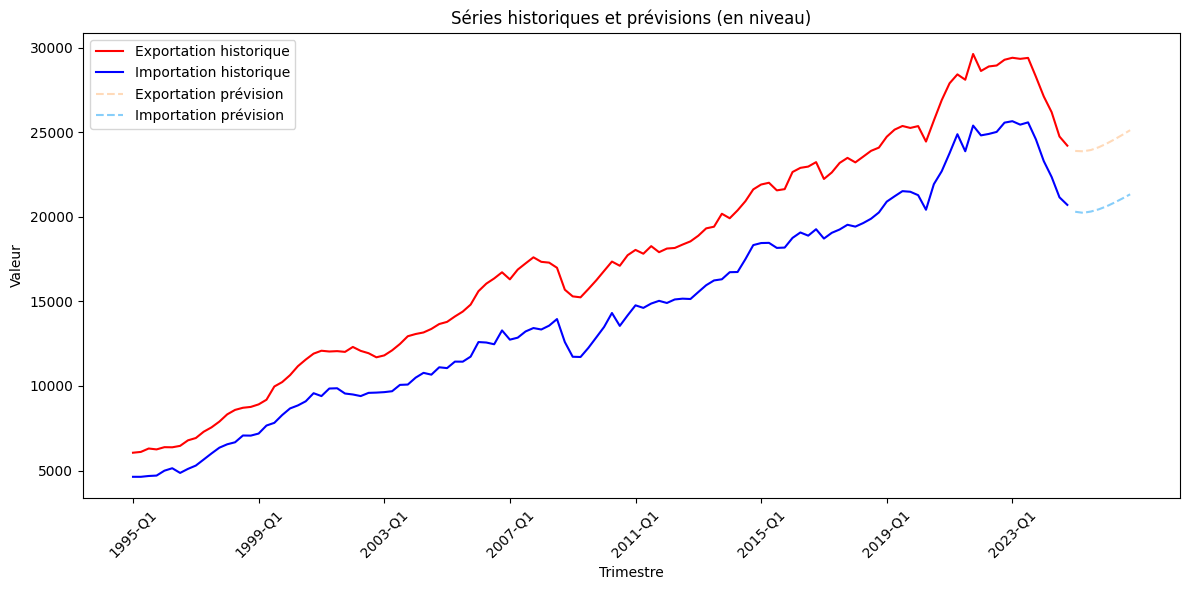

In [65]:
# Graph mais avant on doit passer les série de log à niveau avec l'exponentiel

# Appliquer np.exp colonne par colonne et garder l'index avec pandas
serie_exp = serie.copy()
serie_exp["logX"] = np.exp(serie["logX"])
serie_exp["logM"] = np.exp(serie["logM"])

forecast_exp = forecast_df.copy()
forecast_exp["logX"] = np.exp(forecast_df["logX"])
forecast_exp["logM"] = np.exp(forecast_df["logM"])

# Maintenant on peut tracer avec l'index conservé
plt.figure(figsize=(12, 6))

plt.plot(
    serie_exp.index,
    serie_exp["logX"],
    label="Exportation historique",
    color="red",
    linestyle="-",
)
plt.plot(
    serie_exp.index,
    serie_exp["logM"],
    label="Importation historique",
    color="blue",
    linestyle="-",
)
plt.plot(
    forecast_exp.index,
    forecast_exp["logX"],
    label="Exportation prévision",
    color="peachpuff",
    linestyle="--",
)
plt.plot(
    forecast_exp.index,
    forecast_exp["logM"],
    label="Importation prévision",
    color="lightskyblue",
    linestyle="--",
)

# Pour gérer les ticks x, on prend un tick tous les 16 trimestres (4 ans)
ticks_to_use = serie_exp.index.union(forecast_exp.index)[::16]

plt.xticks(ticks_to_use, rotation=45)  # on affiche seulement ces ticks avec rotation


plt.title("Séries historiques et prévisions (en niveau)")
plt.xlabel("Trimestre")
plt.ylabel("Valeur")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_3556/3250496984.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  serie_exp.index = pd.to_datetime(serie_exp.index)
/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_3556/3250496984.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  forecast_exp.index = pd.to_datetime(forecast_exp.index)


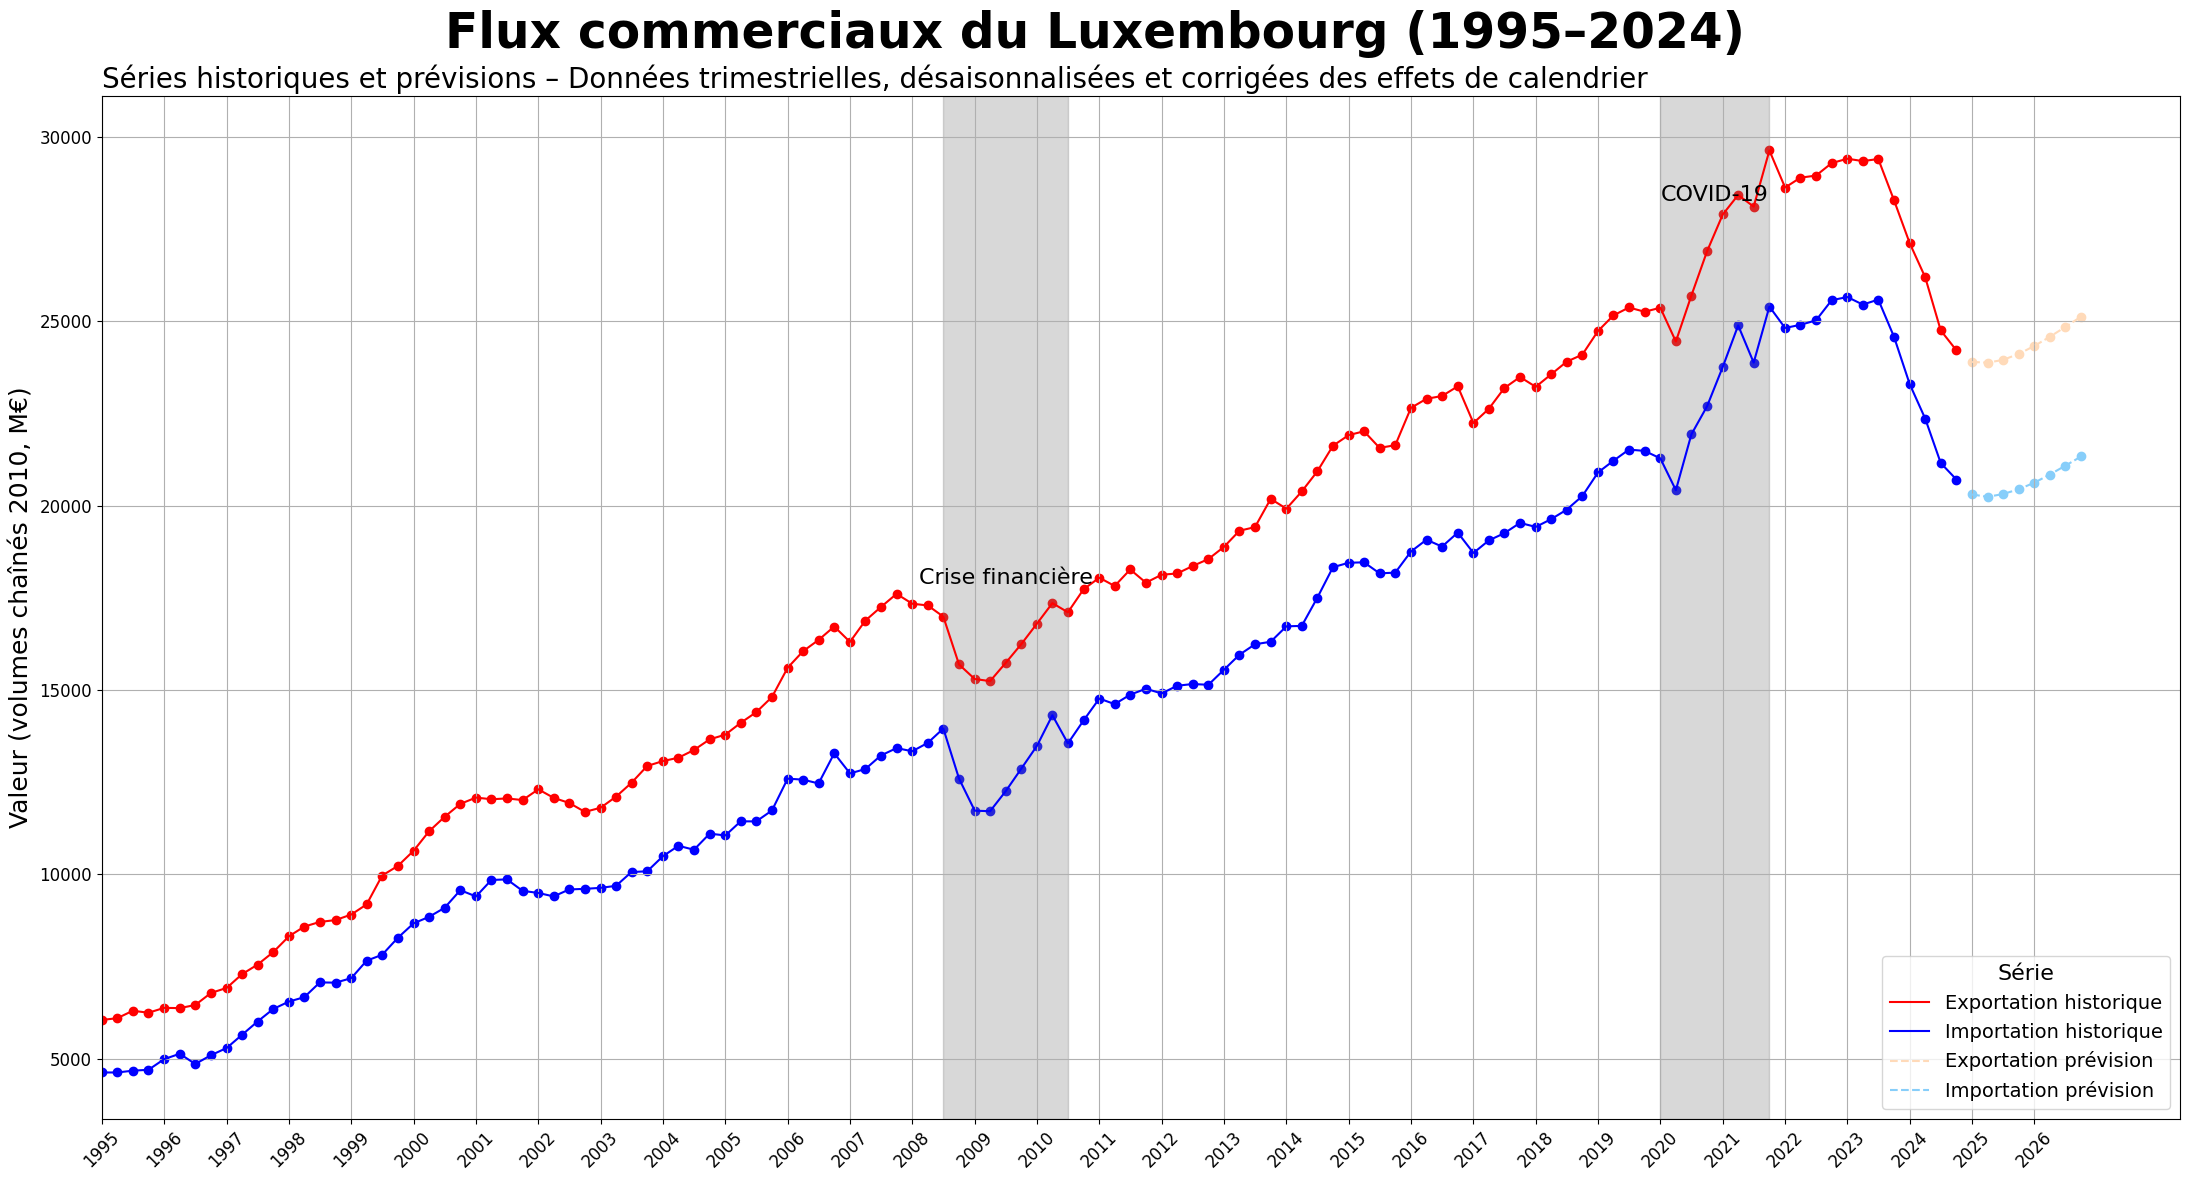

In [66]:
# Même graphique mais en mieux

# Exponentiation des séries
serie_exp = serie.copy()
serie_exp["logX"] = np.exp(serie["logX"])
serie_exp["logM"] = np.exp(serie["logM"])

forecast_exp = forecast_df.copy()
forecast_exp["logX"] = np.exp(forecast_df["logX"])
forecast_exp["logM"] = np.exp(forecast_df["logM"])

# S'assurer que l'index est bien en datetime
serie_exp.index = pd.to_datetime(serie_exp.index)
forecast_exp.index = pd.to_datetime(forecast_exp.index)

# Fusion des index pour définir les ticks
full_index = serie_exp.index.union(forecast_exp.index)

# Création de la figure
plt.figure(figsize=(22, 12))

# Courbes historiques
plt.plot(
    serie_exp.index,
    serie_exp["logX"],
    label="Exportation historique",
    color="red",
    linestyle="-",
)
plt.plot(
    serie_exp.index,
    serie_exp["logM"],
    label="Importation historique",
    color="blue",
    linestyle="-",
)

# Courbes prévisionnelles
plt.plot(
    forecast_exp.index,
    forecast_exp["logX"],
    label="Exportation prévision",
    color="peachpuff",
    linestyle="--",
)
plt.plot(
    forecast_exp.index,
    forecast_exp["logM"],
    label="Importation prévision",
    color="lightskyblue",
    linestyle="--",
)

# Points historiques
plt.scatter(serie_exp.index, serie_exp["logX"], color="red")
plt.scatter(serie_exp.index, serie_exp["logM"], color="blue")

# Points prévisionnels
plt.scatter(forecast_exp.index, forecast_exp["logX"], color="peachpuff")
plt.scatter(forecast_exp.index, forecast_exp["logM"], color="lightskyblue")

# Définir la hauteur max pour annotations
y_max = max(
    serie_exp[["logX", "logM"]].max().max(), forecast_exp[["logX", "logM"]].max().max()
)
plt.ylim(top=y_max * 1.05)

# Zones grisées pour les crises
crise_fin_start = pd.Timestamp("2008-07-01")
crise_fin_end = pd.Timestamp("2010-06-30")
covid_start = pd.Timestamp("2020-01-01")
covid_end = pd.Timestamp("2021-09-30")

plt.axvspan(crise_fin_start, crise_fin_end, color="grey", alpha=0.3)
plt.axvspan(covid_start, covid_end, color="grey", alpha=0.3)

# Annotations des crises
plt.text(
    x=crise_fin_start + (crise_fin_end - crise_fin_start) / 2,
    y=y_max * 0.6,
    s="Crise financière",
    fontsize=16,
    ha="center",
    va="bottom",
    color="black",
)

plt.text(
    x=covid_start + (covid_end - covid_start) / 2,
    y=y_max * 0.95,
    s="COVID-19",
    fontsize=16,
    ha="center",
    va="bottom",
    color="black",
)

# Titres et labels
plt.xlabel(None)
plt.ylabel("Valeur (volumes chaînés 2010, M€)", fontsize=18)
plt.title(
    "Séries historiques et prévisions – Données trimestrielles, désaisonnalisées et corrigées des effets de calendrier",
    fontsize=20,
    loc="left",
)
plt.suptitle(
    "Flux commerciaux du Luxembourg (1995–2024)", fontsize=35, fontweight="bold"
)

# Légende
plt.legend(
    title="Série",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    bbox_to_anchor=(1, 0),
)

# Grille
plt.grid(True)

# Axe des x – affichage des années
plt.xlim(left=pd.Timestamp("1995-01-01"))
plt.xticks(
    pd.date_range(start="1995-01-01", end=full_index.max(), freq="YS"),
    fontsize=12,
    rotation=45,
)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Axe des y
plt.yticks(fontsize=12)

# Affichage
plt.tight_layout()
plt.show()

### Comment présenter les résultats en tableau ?

In [67]:
forecast_exp.columns = ["Exportation", "Importation"]
forecast_exp = forecast_exp.round(2)

# Renommer l’index s’il a un sens (optionnel)
forecast_exp.index.name = "Annee"  # ou "Ligne", "Index", etc.

# Convertir en HTML avec les lignes (index)
html_table = forecast_exp.to_html(index=True)

# Sauvegarder dans un fichier HTML
with open("tableau_forecast.html", "w") as f:
    f.write(html_table)

### Taux de croissance

In [68]:
# Calculer le taux de croissance pour les variables prévisionnelles en niveau
growth_rates = forecast_exp[["Exportation", "Importation"]].pct_change()

# Renommer les colonnes pour refléter qu'il s'agit de taux de croissance
growth_rates.columns = ["growth_X", "growth_M"]

# Afficher les résultats
print(growth_rates)

growth_rates_percent = growth_rates * 100

# Afficher les résultats
print(growth_rates_percent)

            growth_X  growth_M
Annee                         
2025-01-01       NaN       NaN
2025-04-01 -0.000865 -0.003138
2025-07-01  0.003162  0.003731
2025-10-01  0.006835  0.006409
2026-01-01  0.008924  0.008752
2026-04-01  0.010190  0.010713
2026-07-01  0.010837  0.011429
2026-10-01  0.011258  0.011855
            growth_X  growth_M
Annee                         
2025-01-01       NaN       NaN
2025-04-01 -0.086548 -0.313847
2025-07-01  0.316166  0.373146
2025-10-01  0.683452  0.640917
2026-01-01  0.892394  0.875220
2026-04-01  1.019037  1.071306
2026-07-01  1.083710  1.142910
2026-10-01  1.125831  1.185546


In [69]:
growth_rates_percent = growth_rates_percent.round(2)

# Renommer l’index s’il a un sens (optionnel)
growth_rates_percent.index.name = "Annee"  # ou "Ligne", "Index", etc.

# Convertir en HTML avec les lignes (index)
html_table = growth_rates_percent.to_html(index=True)

# Sauvegarder dans un fichier HTML
with open("tableau_forecast_growth.html", "w") as f:
    f.write(html_table)

# <center>Fin